# Chen SBML Model NNSE (Filler + Jackknife)
This notebook adapts the NNSE / NNSEFunc approach used for the Tyson model to the Chen (2004) budding yeast cell cycle model.
Uses the SBML model via Tellurium/RoadRunner and applies Gaussian mutations in normalized parameter space.
Includes parallel mutations and jackknife stability diagnostics.

In [1]:
# Imports
import tellurium as te
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import platform
import roadrunner
import math
import multiprocessing as mp
from multiprocessing import Pool, cpu_count
import psutil
import warnings
import copy
import time
warnings.filterwarnings('ignore')

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm as tqdm_text
    tqdm = tqdm_text

    print("Note: Using text-based progress bar. For better display, install ipywidgets.")
    print("="*60)

print("🧪 ChenNNSEFunc_Filler + Jackknife: NNSE for Chen 2004 Yeast Cell Cycle Model")

# Silence RoadRunner log messages
roadrunner.Logger.setLevel(roadrunner.Logger.LOG_CRITICAL)

🧪 ChenNNSEFunc_Filler + Jackknife: NNSE for Chen 2004 Yeast Cell Cycle Model


In [2]:
# === CPU OPTIMIZATION DETECTION ===
def detect_cpu_config():
    """Detect optimal CPU configuration for Radeon/AMD processors"""
    cpu_count_total = cpu_count()
    cpu_info = platform.processor()
    
    # Check if this is an AMD/Radeon CPU
    is_amd = any(keyword in cpu_info.lower() for keyword in ['amd', 'radeon', 'ryzen', 'epyc', 'athlon'])
    
    if is_amd:
        try:
            physical_cores = psutil.cpu_count(logical=False)
            logical_cores = psutil.cpu_count(logical=True)
            optimal_workers = max(1, int(physical_cores * 0.8)) if physical_cores else max(1, int(cpu_count_total * 0.7))
            print(f"🔧 AMD/Radeon CPU detected: {cpu_info}")
            print(f"   Physical cores: {physical_cores}, Logical cores: {logical_cores}")
            print(f"   Optimal workers for simulation: {optimal_workers}")
            return optimal_workers, True
        except:
            optimal_workers = max(1, int(cpu_count_total * 0.7))
            print(f"🔧 AMD CPU detected (fallback): using {optimal_workers} workers")
            return optimal_workers, True
    else:
        optimal_workers = max(1, cpu_count_total - 1)
        print(f"🔧 Non-AMD CPU: using {optimal_workers} workers")
        return optimal_workers, False

OPTIMAL_WORKERS, IS_AMD_CPU = detect_cpu_config()

# Cross-platform path detection
def get_model_path():
    """Get the correct path to the SBML model file based on OS and available paths."""
    linux_path = "/home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"
    Beecroft_path = "/home/b/bartholomeus/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"   
    mac_path = "/Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen_model.xml"
    
    if os.path.exists(linux_path):
        print("linux_path")
        return linux_path
    elif os.path.exists(mac_path):
        return mac_path
    elif os.path.exists(Beecroft_path):
        print("Beecroft_path")
        return Beecroft_path
    else:
        possible_relative_paths = ["chen_model.xml", "Chen/chen_model.xml", "../Chen/chen_model.xml", "../../Yeast/Chen/chen_model.xml"]
        for rel_path in possible_relative_paths:
            if os.path.exists(rel_path):
                return os.path.abspath(rel_path)
        raise FileNotFoundError(f"Could not find chen_model.xml in any of the expected locations:\n  Linux: {linux_path}\n  Mac: {mac_path}\nCurrent working directory: {os.getcwd()}\nPlatform: {platform.system()}")

# Load Chen 2004 budding yeast cell cycle model
model_path = get_model_path()
print(f"Loading model from: {model_path}")
rr = te.loadSBMLModel(model_path)
print("✓ Chen model loaded successfully")

🔧 Non-AMD CPU: using 11 workers
Beecroft_path
Loading model from: /home/b/bartholomeus/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml
✓ Chen model loaded successfully


In [3]:
# === CONFIGURATION VARIABLES ===
# NNSE settings
SIGMA = 0.01             # Gaussian mutation sigma in normalized u-space
N_Vec = 50               # Number of bins / maintained parameter vectors

# Main loop adaptive stopping settings
HARD_MAX_MAIN_LOOP = int(5e5)  # Maximum steps for main NNSE loop
TARGET_EMPTY_MAIN = 1          # Continue until only this many bins empty
EXTRA_STEPS_MAIN = 1000        # Continue this many steps after reaching target

# Simulation settings
T_START = 50.0
T_END = 500.0            # Chen system simulation time (minutes)
N_TIME_POINTS = 501
DIVERGENCE_THRESHOLD = 100  # Reject divergent solutions

# === BIN THRESHOLDS CONFIGURATION ===
BIN_SPACING_TYPE = 'log'  # Options: 'log' (logarithmic) or 'linear'
BIN_MIN = 1e-2             # Minimum threshold for first bin
BIN_MAX = 25e1             # Maximum threshold for second-to-last bin
BIN_TOP = 1e3             # Very high threshold for last bin
K_INITIAL=20
# Create bin thresholds based on spacing type
if BIN_SPACING_TYPE == 'log':
    bin_thresholds_log = np.logspace(np.log10(BIN_MIN), np.log10(BIN_MAX), N_Vec)
else:  # linear
    bin_thresholds_log = np.linspace(BIN_MIN, BIN_MAX, N_Vec)

bin_thresholds = np.append(bin_thresholds_log, BIN_TOP)  # Add very high top bin
print(f"   Spacing type: {BIN_SPACING_TYPE}")
print(f"   Total thresholds: {len(bin_thresholds)} (N_Vec={N_Vec} + 1 top bin)")
print(f"   Range: {bin_thresholds[0]:.3e} to {bin_thresholds[-2]:.3e} (top: {bin_thresholds[-1]:.3e})")
print(f"   First 10 thresholds:")
print(f"   SIGMA: {SIGMA}")
print(f"   T_END: {T_END} min")
print(f"   K_INITIAL: {K_INITIAL}")
print(f"\n📊 BIN THRESHOLD SPACING:")
print(f"   Total thresholds: {len(bin_thresholds)} (N_Vec={N_Vec} log-spaced + 1 manual high)")

print(f"   Max threshold: {bin_thresholds[-1]:.6e} (manually set)")

for i in range(min(10, len(bin_thresholds))):    
    print(f"      y[{i}] = {bin_thresholds[i]:.6e}")

   Spacing type: log
   Total thresholds: 51 (N_Vec=50 + 1 top bin)
   Range: 1.000e-02 to 2.500e+02 (top: 1.000e+03)
   First 10 thresholds:
   SIGMA: 0.01
   T_END: 500.0 min
   K_INITIAL: 20

📊 BIN THRESHOLD SPACING:
   Total thresholds: 51 (N_Vec=50 log-spaced + 1 manual high)
   Max threshold: 1.000000e+03 (manually set)
      y[0] = 1.000000e-02
      y[1] = 1.229572e-02
      y[2] = 1.511847e-02
      y[3] = 1.858924e-02
      y[4] = 2.285680e-02
      y[5] = 2.810408e-02
      y[6] = 3.455598e-02
      y[7] = 4.248906e-02
      y[8] = 5.224335e-02
      y[9] = 6.423695e-02


In [4]:
# === CORE FUNCTIONS ===

def get_kinetic_parameters(rr):
    """Get list of kinetic parameters, excluding regulatory switches/flags."""
    kinetic_params = []
    excluded_params = []
    
    for pid in rr.getGlobalParameterIds():
        value = rr.getValue(pid)
        param_lower = pid.lower()
        
        # Exclude non-kinetic parameters (switches, flags, totals)
        if (param_lower.endswith('t') and value in [0.0, 1.0]) or \
           (param_lower.startswith('d') and param_lower.endswith('n')) or \
           ('flag' in param_lower) or \
           ('switch' in param_lower) or \
           (value == 0.0) or \
           (pid in ['cell']) or \
           ('total' in param_lower and value in [0.0, 1.0]):
            excluded_params.append(pid)
        else:
            kinetic_params.append(pid)
    
    return kinetic_params, excluded_params

# Get kinetic parameters and cache default values
kinetic_params_all, excluded_params = get_kinetic_parameters(rr)
default_values_all = {pid: rr.getValue(pid) for pid in kinetic_params_all}

print(f"✓ Initial filtering: {len(kinetic_params_all)} kinetic parameters")
print(f"   Excluded {len(excluded_params)} non-kinetic parameters (switches/flags/totals)")

# === SECOND FILTERING STEP: Remove parameters with zero default values ===
# These cannot be normalized in the hypercube embedding (u = p / (2*p0))
kinetic_params = []
zero_params = []
for pid in kinetic_params_all:
    value = default_values_all[pid]
    if value == 0.0:
        zero_params.append(pid)
    else:
        kinetic_params.append(pid)

# Create dictionaries for mutable parameters only
default_values = {pid: default_values_all[pid] for pid in kinetic_params}
n_params = len(kinetic_params)

print(f"\n✓ Second filtering: Removed {len(zero_params)} parameters with zero default values")
if len(zero_params) > 0:
    print(f"   Zero-valued parameters (excluded from mutation): {zero_params}")

print(f"\n✓ FINAL: {n_params} parameters will be mutated")
print(f"   Total excluded: {len(excluded_params) + len(zero_params)}")

# Create p0_vec (default parameter values as vector) - only for mutable parameters
p0_vec = np.array([default_values[pid] for pid in kinetic_params], dtype=float)

# Verify no zeros in p0_vec
if np.any(p0_vec == 0.0):
    raise ValueError(f"ERROR: p0_vec still contains zeros! This will cause division by zero.")

# Print all mutable parameters with their default values
print(f"\n📋 ALL MUTABLE PARAMETERS WITH DEFAULT VALUES:")
print(f"{'Parameter':<20} {'Default Value':<20}")
print("-" * 40)
for pid in kinetic_params:
    print(f"{pid:<20} {default_values[pid]:<20.6e}")
print(f"\nTotal mutable parameters: {n_params}")

✓ Initial filtering: 156 kinetic parameters
   Excluded 7 non-kinetic parameters (switches/flags/totals)

✓ Second filtering: Removed 0 parameters with zero default values

✓ FINAL: 156 parameters will be mutated
   Total excluded: 7

📋 ALL MUTABLE PARAMETERS WITH DEFAULT VALUES:
Parameter            Default Value       
----------------------------------------
b0                   5.400000e-02        
bub2h                1.000000e+00        
bub2l                2.000000e-01        
C0                   4.000000e-01        
Dn3                  1.000000e+00        
ebudb5               1.000000e+00        
ebudn2               2.500000e-01        
ebudn3               5.000000e-02        
ec1b2                4.500000e-01        
ec1b5                1.000000e-01        
ec1k2                3.000000e-02        
ec1n2                6.000000e-02        
ec1n3                3.000000e-01        
ef6b2                5.500000e-01        
ef6b5                1.000000e-01        
ef6k2 

In [5]:
# === SIMULATION FUNCTIONS ===

def simulate_chen(rr, T=None, npoints=None):
    """Simulate Chen system and return CLB2 time series"""
    if T is None:
        T = T_END
    if npoints is None:
        npoints = N_TIME_POINTS
    
    # Set selections to minimum required
    rr.selections = ["time", "CLB2"]
    
    try:
        result = rr.simulate(0, T, npoints)
    except RuntimeError as e:
        return None, None
    
    time = result[:, 0]
    clb2 = result[:, 1]
    
    # Check for divergence
    if np.any(np.abs(clb2) > DIVERGENCE_THRESHOLD):
        return "divergent", None
    
    return time, clb2

def reset_model_to_params(rr, P_vec, kinetic_params_list, default_vals):
    """Reset model to default values and set new parameter vector"""
    # Reset to defaults
    for pid, default_val in default_vals.items():
        try:
            rr.setValue(pid, default_val)
        except RuntimeError:
            continue
    rr.resetAll()
    
    # Set new parameter values
    for i, pid in enumerate(kinetic_params_list):
        try:
            rr.setValue(pid, float(P_vec[i]))
        except (RuntimeError, IndexError):
            continue

print("✓ Simulation functions defined")

✓ Simulation functions defined


In [6]:
# === SIM FUNCTION (objective) with improved thread-safe caching ===

import threading

# Thread-safe cache for roadrunner instances (one per thread/process)
_rr_cache = {}
_cache_lock = threading.Lock()

def get_cached_rr():
    """Get or create a cached RoadRunner instance for this thread/process.
    Thread-safe implementation ensures each thread gets its own model instance.
    """
    # Get unique identifier for current thread/process
    thread_id = threading.current_thread().ident
    process_id = mp.current_process().pid
    cache_key = (process_id, thread_id)
    
    # Check if we already have a cached instance for this thread/process
    if cache_key not in _rr_cache:
        with _cache_lock:
            # Double-check after acquiring lock
            if cache_key not in _rr_cache:
                _rr_cache[cache_key] = te.loadSBMLModel(model_path)
    
    return _rr_cache[cache_key]

def sim(P_vec):
    """Simulate with parameter vector P_vec and compute integrated squared difference
    against the reference simulation (p0). Returns scalar squared-difference.
    
    Uses thread-safe cached model instances to avoid repeatedly loading SBML.
    """
    # Use cached model instance instead of loading fresh each time
    rr_local = get_cached_rr()
    
    # Set parameters
    reset_model_to_params(rr_local, P_vec, kinetic_params, default_values)
    
    try:
        t, clb2 = simulate_chen(rr_local, T_END, N_TIME_POINTS)
        
        if t is None or isinstance(t, str):
            return float(np.inf)
        
        # Interpolate reference to match t
        clb2_0_interp = np.interp(t, t0_ref, clb2_0_ref)
        
        # Squared differences
        d_clb2_sq = (clb2 - clb2_0_interp) ** 2
        
        # Integrate over time
        integral = np.trapz(d_clb2_sq, t)
        return float(integral)
        
    except Exception as e:
        print(f'Warning: Simulation failed during sim(): {e}')
        return float(np.inf)

print('✓ sim() defined with thread-safe RoadRunner caching')
print('  Each thread/process maintains its own cached model instance')

✓ sim() defined with thread-safe RoadRunner caching
  Each thread/process maintains its own cached model instance


Running reference simulation with default parameters...
✓ Reference simulation complete
   Time range: 0.0 - 500.0 min
   CLB2 range: 0.000 - 1.432

Generating random parameter sets for comparison...
✓ Successfully simulated 5/9 mutants (55.6% success rate)

Mutant     f-value        
-------------------------
1          2.32e+02       
2          2.50e+05       
3          1.36e+04       
4          5.21e+04       
5          1.69e+04       

Parameter                      x1           x2           x3           x4           x5 
b0                        8.5e-02      9.2e-02      6.2e-02      5.3e-02      9.2e-02 
bub2h                     1.7e+00      1.1e+00      4.6e-01      5.6e-01      1.1e+00 
bub2l                     2.5e-01      2.4e-01      4.0e-01      2.6e-01      7.5e-02 
C0                        6.7e-01      7.8e-01      6.4e-02      3.6e-01      3.4e-01 
Dn3                       1.3e-02      1.4e+00      2.5e-02      4.2e-01      1.5e+00 
ebudb5                    5.6e

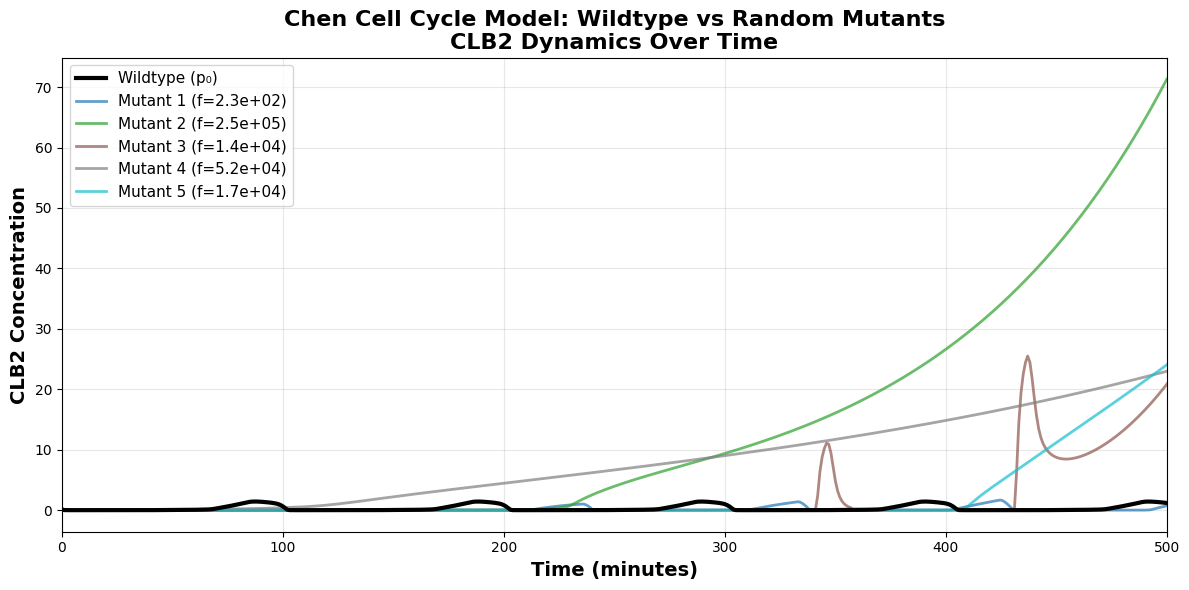


✓ Plotted wildtype vs 5 random mutants
   Objective function f measures integrated squared difference from wildtype
   Lower f = closer to wildtype behavior (sloppy parameters)
   Higher f = more divergent behavior


In [7]:
# === REFERENCE SIMULATION (p0) ===
print("Running reference simulation with default parameters...")
reset_model_to_params(rr, p0_vec, kinetic_params, default_values)
t0_ref, clb2_0_ref = simulate_chen(rr, T_END, N_TIME_POINTS)

if t0_ref is None or isinstance(t0_ref, str):
    raise RuntimeError("Reference simulation failed!")

print(f"✓ Reference simulation complete")
print(f"   Time range: {t0_ref[0]:.1f} - {t0_ref[-1]:.1f} min")
print(f"   CLB2 range: {np.min(clb2_0_ref):.3f} - {np.max(clb2_0_ref):.3f}")

# === PLOT: Wildtype vs Random Mutants ===
print("\nGenerating random parameter sets for comparison...")
N_RANDOM_MUTANTS = 5  # Number of successful mutants to plot

# Generate random parameter vectors
random_P_vecs = []
random_clb2_traces = []
random_f_values = []

attempts = 0
max_attempts = 100  # Prevent infinite loop

# Create a reusable RoadRunner instance for random mutants
rr_rand = te.loadSBMLModel(model_path)

while len(random_clb2_traces) < N_RANDOM_MUTANTS and attempts < max_attempts:
    attempts += 1
    
    # Generate random parameter vector in hypercube
    u_rand = np.random.uniform(0.0, 1.0, size=n_params)
    P_rand = 2.0 * p0_vec * u_rand
    
    # Simulate (reusing the same RoadRunner instance)
    reset_model_to_params(rr_rand, P_rand, kinetic_params, default_values)
    t_rand, clb2_rand = simulate_chen(rr_rand, T_END, N_TIME_POINTS)
    
    # Only keep if simulation succeeded
    if t_rand is not None and not isinstance(t_rand, str):
        random_P_vecs.append(P_rand)
        random_clb2_traces.append((t_rand, clb2_rand))
        # Calculate objective value
        f_val = sim(P_rand)
        random_f_values.append(f_val)

# Print summary
success_rate = len(random_clb2_traces) / attempts * 100 if attempts > 0 else 0
print(f"✓ Successfully simulated {len(random_clb2_traces)}/{attempts} mutants ({success_rate:.1f}% success rate)")

# Print table of mutants and f-values
if len(random_clb2_traces) > 0:
    print(f"\n{'Mutant':<10} {'f-value':<15}")
    print("-" * 25)
    for i, f_val in enumerate(random_f_values, 1):
        print(f"{i:<10} {f_val:<15.2e}")
    
    # Print table of first 15 parameters for first 5 mutants
    n_params_show = min(15, n_params)
    n_mutants_show = min(5, len(random_P_vecs))
    
    print(f"\n{'Parameter':<20} ", end="")
    for i in range(n_mutants_show):
        print(f"{'x' + str(i+1):>12} ", end="")
    print()
    print("=" * (20 + 13 * n_mutants_show))
    
    for param_idx in range(n_params_show):
        param_name = kinetic_params[param_idx]
        print(f"{param_name:<20} ", end="")
        for mutant_idx in range(n_mutants_show):
            val = random_P_vecs[mutant_idx][param_idx]
            # Format as scientific notation with 1 decimal place
            print(f"{val:>12.1e} ", end="")
        print()

# Create comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot wildtype (reference) with thick black line
ax.plot(t0_ref, clb2_0_ref, 'k-', linewidth=3, label='Wildtype (p₀)', zorder=10)

# Plot random mutants with different colors
colors = plt.cm.tab10(np.linspace(0, 1, len(random_clb2_traces)))
for idx, ((t_rand, clb2_rand), f_val) in enumerate(zip(random_clb2_traces, random_f_values)):
    ax.plot(t_rand, clb2_rand, color=colors[idx], linewidth=2, alpha=0.7,
            label=f'Mutant {idx+1} (f={f_val:.1e})')

ax.set_xlabel('Time (minutes)', fontsize=14, fontweight='bold')
ax.set_ylabel('CLB2 Concentration', fontsize=14, fontweight='bold')
ax.set_title('Chen Cell Cycle Model: Wildtype vs Random Mutants\nCLB2 Dynamics Over Time', 
             fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, T_END])

plt.tight_layout()
plt.show()

print(f"\n✓ Plotted wildtype vs {len(random_clb2_traces)} random mutants")
print(f"   Objective function f measures integrated squared difference from wildtype")
print(f"   Lower f = closer to wildtype behavior (sloppy parameters)")
print(f"   Higher f = more divergent behavior")

In [8]:
# === ChenNNSEFunc: mutation + permutation + vacancy filling (with parallel support) ===

def _mutate_worker(args):
    """Worker function for parallel mutation."""
    i, xi, fxi, p0_vec_val, SIGMA_val, n_params_val, bin_thresholds_val = args
    
    if xi is None or fxi is None:
        return (i, None, None)
    
    u_vec = xi / (2.0 * p0_vec_val)
    u_mutated = (u_vec + np.random.normal(0, SIGMA_val, size=n_params_val)) % 1.0
    xi_prime = 2.0 * p0_vec_val * u_mutated
    fxi_prime = sim(xi_prime)
    
    if fxi_prime > bin_thresholds_val[i]:
        return (i, xi.copy(), fxi)
    else:
        return (i, xi_prime, fxi_prime)

def ChenNNSEFunc(X_list, fX_list, pool=None):
    """Mutate each parameter vector, accept/reject based on thresholds, then permute.
    Args:
        X_list: list of parameter vectors (numpy arrays) or None for empty positions
        fX_list: list of scalar function values or None for empty positions
        pool: multiprocessing Pool for parallel mutations (optional)
    Returns: (v_list, fv_list, fX_prime_list, swaps)
    """
    n = len(X_list)
    
    # Step 1 & 2: Mutate each position
    if pool is not None:
        # PARALLEL: Use worker pool
        work_items = [
            (i, X_list[i], fX_list[i], p0_vec, SIGMA, n_params, bin_thresholds)
            for i in range(n) if X_list[i] is not None
        ]
        if work_items:
            results = pool.map(_mutate_worker, work_items)
            results_dict = {idx: (x, fx) for idx, x, fx in results}
        else:
            results_dict = {}
        X_prime_list = [results_dict.get(i, (None, None))[0] for i in range(n)]
        fX_prime_list = [results_dict.get(i, (None, None))[1] for i in range(n)]
    else:
        # SERIAL: Original loop
        X_prime_list = []
        fX_prime_list = []
        
        for i in range(n):
            xi = X_list[i]
            fxi = fX_list[i]
            
            if xi is None or fxi is None:
                X_prime_list.append(None)
                fX_prime_list.append(None)
                continue
            
            u_vec = xi / (2.0 * p0_vec)
            u_mutated = u_vec + np.random.normal(0, SIGMA, size=n_params)
            u_mutated = u_mutated % 1.0
            xi_prime = 2.0 * p0_vec * u_mutated
            fxi_prime = sim(xi_prime)
            
            if fxi_prime > bin_thresholds[i]:
                X_prime_list.append(xi.copy())
                fX_prime_list.append(fxi)
            else:
                X_prime_list.append(xi_prime)
                fX_prime_list.append(fxi_prime)
    
    # Permutation step (bubble up better entries)
    v_list = X_prime_list.copy()
    fv_list = fX_prime_list.copy()
    
    empty_before = set(i for i in range(n) if v_list[i] is None or fv_list[i] is None)
    swaps = []
    
    for i in range(n-1, 0, -1):
        if fv_list[i] is None and fv_list[i-1] is None:
            continue
        
        if fv_list[i] is not None and fv_list[i] <= bin_thresholds[i-1]:
            if v_list[i] is not None and v_list[i-1] is not None:
                v_list[i], v_list[i-1] = v_list[i-1].copy(), v_list[i].copy()
            else:
                v_list[i], v_list[i-1] = v_list[i-1], v_list[i]
            fv_list[i], fv_list[i-1] = fv_list[i-1], fv_list[i]
            swaps.append((i, i-1))
    
    # Fill newly empty positions
    empty_after = set(i for i in range(n) if v_list[i] is None or fv_list[i] is None)
    newly_empty = empty_after - empty_before
    
    for empty_pos in newly_empty:
        max_attempts = 1000
        for attempt in range(max_attempts):
            u_random = np.random.uniform(0, 1, size=n_params)
            x_new = 2.0 * p0_vec * u_random
            fx_new = sim(x_new)
            
            placed = False
            for pos in range(n):
                if fx_new <= bin_thresholds[pos]:
                    if v_list[pos] is None or fv_list[pos] is None:
                        v_list[pos] = x_new
                        fv_list[pos] = fx_new
                        placed = True
                        break
                    elif fv_list[pos] is not None and fx_new < fv_list[pos]:
                        v_list[pos] = x_new
                        fv_list[pos] = fx_new
                        placed = True
                        break
            
            if placed:
                break
    
    return v_list, fv_list, fX_prime_list, swaps

n_cores = mp.cpu_count()
print(f'  Detected {n_cores} CPU cores available for parallel mode')
print(f'✓ ChenNNSEFunc defined (parallel & serial modes)')

  Detected 12 CPU cores available for parallel mode
✓ ChenNNSEFunc defined (parallel & serial modes)


In [9]:
# === NNSE INITIALIZATION ===

# Define number of bins and number of initial filled positions
n = N_Vec + 1  # Total number of positions (bins + 1)
K = K_INITIAL  # Number of worst positions to initially fill

# Initialize storage
X_list = [None] * n  # List of parameter vectors (None for empty positions)
fX_list = [None] * n  # List of objective function values (None for empty)

# Create worker pool for parallel mutations
worker_pool = mp.Pool(processes=OPTIMAL_WORKERS)

# Tracking variables (for adaptive main loop)
swap_count = np.zeros(N_Vec + 1)  # Track swaps at each position
total_opportunities = np.zeros(N_Vec + 1)  # Track total opportunities for swaps
is_burned_in = False  # Will be set to True when target is reached

# History tracking
all_X = []  # Trajectory of all X_list at each step
all_fX = []  # Trajectory of all fX_list at each step
all_swaps = []  # Record of swaps at each step
volume_ratio_history = []  # Track volume ratios over time
history_interval = max(1, EXTRA_STEPS_MAIN // 20)  # Sample ~20 times during extra steps

print(f"✓ NNSE Initialization complete")
print(f"   Total positions (n): {n}")
print(f"   Initial fill positions (K): {K}")
print(f"   Worker pool: {OPTIMAL_WORKERS} processes")
print(f"   Burn-in: Starts when target reached (≤{TARGET_EMPTY_MAIN} empty bins)")
print(f"   Adaptive stopping: Fill until ≤{TARGET_EMPTY_MAIN} empty OR {HARD_MAX_MAIN_LOOP} steps max")
print(f"   Extra steps after target: {EXTRA_STEPS_MAIN}")

✓ NNSE Initialization complete
   Total positions (n): 51
   Initial fill positions (K): 20
   Worker pool: 11 processes
   Burn-in: Starts when target reached (≤1 empty bins)
   Adaptive stopping: Fill until ≤1 empty OR 500000 steps max
   Extra steps after target: 1000


In [10]:
# === NNSE LOOP ===

# Helper function to format f values and y thresholds, handling None
def format_f_vals(fX_list, n):
    """Format f values and y thresholds for printing, handling None values.
    Returns two strings: (f_vals_str, y_vals_str)
    Always shows all f(xi) and y_i values.
    """
    indices = list(range(n))
    f_vals = [fX_list[i] if i < len(fX_list) else None for i in indices]
    f_vals_str = " ".join([f"{fx:<12.3e}" if fx is not None else f"{'---':<12}" for fx in f_vals])
    y_vals_str = " ".join([f"{bin_thresholds[i]:<12.3e}" for i in indices])
    return f_vals_str, y_vals_str

def format_duration(seconds: float) -> str:
    """Format duration in human-readable format."""
    if seconds >= 3600:
        return f"{seconds/3600:.2f} hr"
    if seconds >= 60:
        return f"{seconds/60:.2f} min"
    return f"{seconds:.2f} sec"

# === INITIALIZATION PHASE ===
# Simple initialization with fixed max attempts
print(f"\n🔄 Starting initialization phase...")
print(f"   Max attempts: 10,000")

MAX_INIT_ATTEMPTS = int(1e4)  # Maximum initialization attempts
successful_placements = 0

# Store all f values for distribution analysis
init_f_values = []

for attempt in range(MAX_INIT_ATTEMPTS):
    # Generate random parameter vector in hypercube
    u_random = np.random.uniform(0, 1, size=n_params)
    xi = 2.0 * p0_vec * u_random
    fxi = sim(xi)
    
    # Store f value for analysis (only finite values)
    if np.isfinite(fxi):
        init_f_values.append(fxi)
    
    # Find the minimum non-empty bin with threshold y > fxi
    best_bin = None
    for pos in range(n):
        if fxi <= bin_thresholds[pos]:  # This bin's threshold is higher than our value
            if X_list[pos] is None:  # This bin is empty, we can place here
                best_bin = pos
                break
            # If bin is already filled, continue to find next empty bin
    
    # Place the parameter set in the best bin if found
    if best_bin is not None:
        X_list[best_bin] = xi
        fX_list[best_bin] = fxi
        successful_placements += 1
        if successful_placements <= 10 or successful_placements % 5 == 0:
            print(f"   Attempt {attempt+1}: Placed f={fxi:.3e} in bin {best_bin} (y={bin_thresholds[best_bin]:.3e})")
    else:
        # Value too large or all appropriate bins full
        if attempt % 2000 == 0 and attempt > 0:
            filled = sum(1 for x in X_list if x is not None)
            print(f"   Attempt {attempt}: f={fxi:.3e} - {filled} positions filled, {n-filled} empty")

# Convert to array for analysis
init_f_values = np.array(init_f_values)

filled = sum(1 for x in X_list if x is not None)
print(f"\n✓ Initialization complete: {filled} positions filled, {n-filled} empty")
print(f"   Total attempts: {attempt+1}")
print(f"   Successful placements: {successful_placements}")
print(f"   Collected {len(init_f_values)} finite f-values for distribution analysis")


🔄 Starting initialization phase...
   Max attempts: 10,000
   Attempt 2: Placed f=1.954e+02 in bin 48 (y=2.033e+02)
   Attempt 5: Placed f=1.777e+02 in bin 49 (y=2.500e+02)
   Attempt 6: Placed f=1.738e+02 in bin 50 (y=1.000e+03)
   Attempt 35: Placed f=1.610e+02 in bin 47 (y=1.654e+02)
   Attempt 598: Placed f=1.322e+02 in bin 46 (y=1.345e+02)
   Attempt 2000: f=7.683e+02 - 5 positions filled, 46 empty
   Attempt 4000: f=9.405e+04 - 5 positions filled, 46 empty
   Attempt 4552: Placed f=9.861e+01 in bin 45 (y=1.094e+02)
   Attempt 6000: f=inf - 6 positions filled, 45 empty
   Attempt 8000: f=inf - 6 positions filled, 45 empty

✓ Initialization complete: 6 positions filled, 45 empty
   Total attempts: 10000
   Successful placements: 6
   Collected 6399 finite f-values for distribution analysis



DISTRIBUTION ANALYSIS FROM INITIALIZATION SAMPLING

Sampling results:
   Total attempts: 10000
   Finite values: 6399 (64.0%)
   Divergent (inf): 3601 (36.0%)

📊 DISTRIBUTION STATISTICS:
   Min f: 9.545e+01
   25th percentile: 1.741e+02
   Median f: 1.802e+02
   75th percentile: 6.773e+03
   95th percentile: 1.927e+05
   Max f: 9.943e+05
   Mean f: 2.909e+04
   Std f: 8.543e+04

📍 COMPARISON WITH BIN THRESHOLDS:
   f ≤ 1.000e-02 (bin 0): 0/6399 (0.00%)
   f ≤ 2.810e-02 (bin 5): 0/6399 (0.00%)
   f ≤ 7.898e-02 (bin 10): 0/6399 (0.00%)
   f ≤ 6.238e-01 (bin 20): 0/6399 (0.00%)
   f ≤ 4.927e+00 (bin 30): 0/6399 (0.00%)
   f ≤ 3.892e+01 (bin 40): 0/6399 (0.00%)
   f ≤ 1.094e+02 (bin 45): 4/6399 (0.06%)
   f ≤ 1.345e+02 (bin 46): 53/6399 (0.83%)
   f ≤ 1.654e+02 (bin 47): 589/6399 (9.20%)
   f ≤ 2.033e+02 (bin 48): 3362/6399 (52.54%)
   f ≤ 2.500e+02 (bin 49): 3532/6399 (55.20%)
   f ≤ 1.000e+03 (bin 50): 4113/6399 (64.28%)


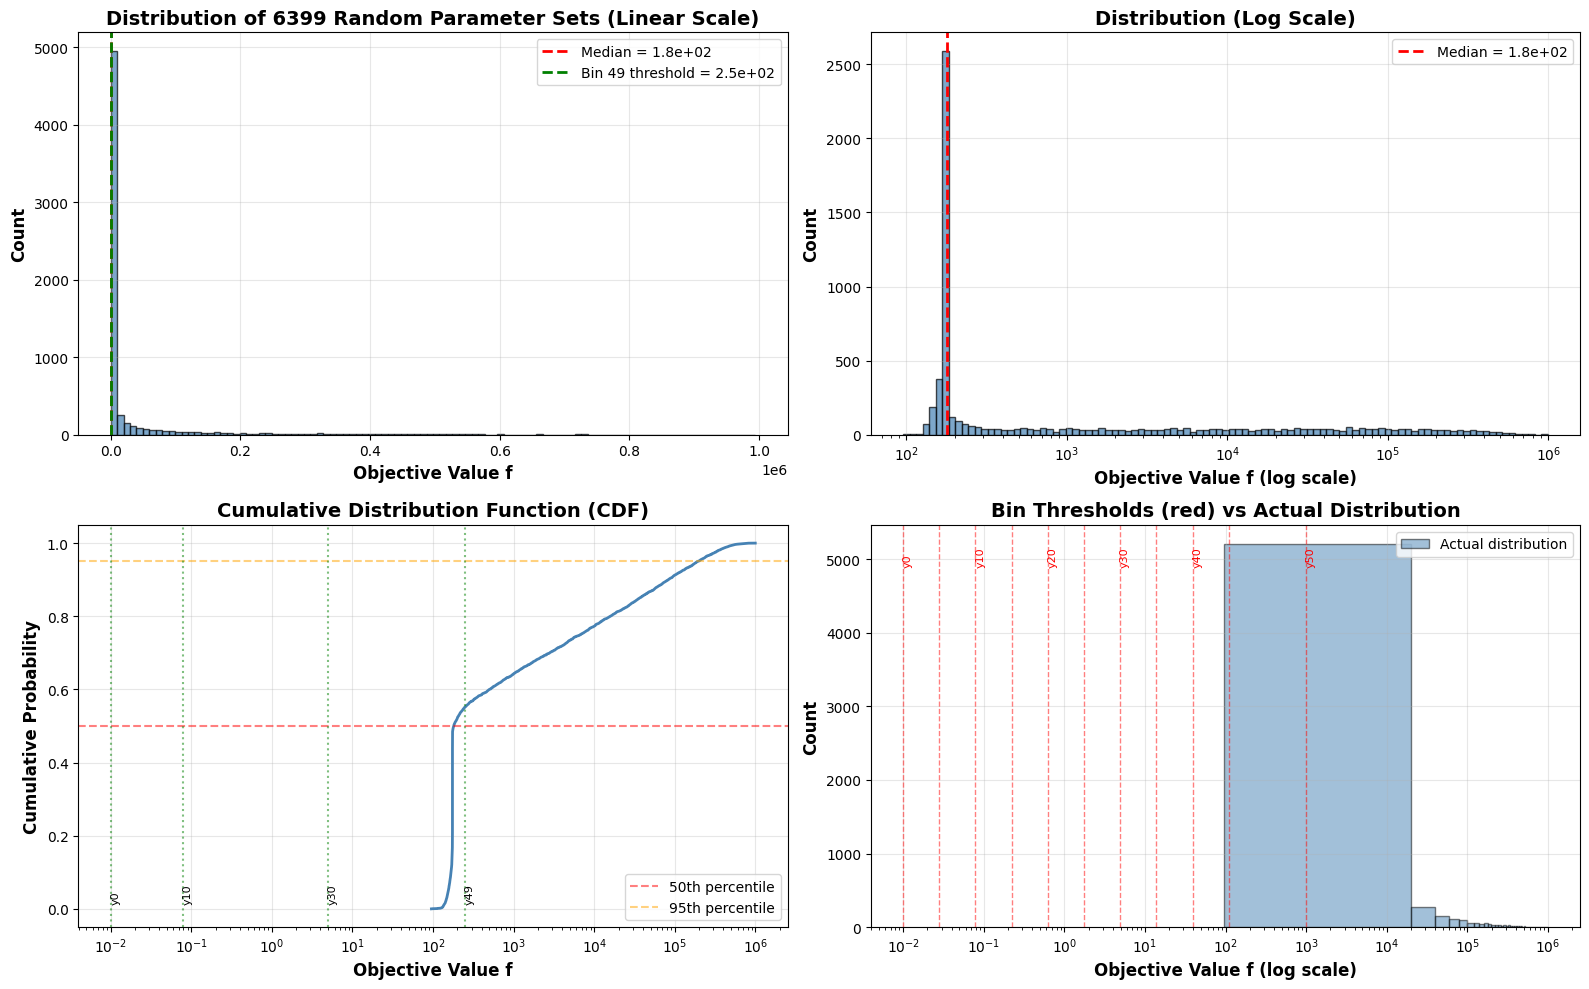


💡 RECOMMENDATION:
   ⚠️  Your bin thresholds are TOO SMALL!
   90% of random samples have f > 1.7e+02
   But bins 0-40 have thresholds < 3.9e+01

   Suggested adjustment:
   bin_thresholds = np.logspace(2.13, 5.65, N_Vec)
   bin_thresholds = np.append(bin_thresholds, 1e9)  # High top bin


In [11]:
# === PLOT DISTRIBUTION OF INITIALIZATION SAMPLING ===

print("\n" + "="*80)
print("DISTRIBUTION ANALYSIS FROM INITIALIZATION SAMPLING")
print("="*80)

n_total = MAX_INIT_ATTEMPTS
n_finite = len(init_f_values)
n_infinite = n_total - n_finite

print(f"\nSampling results:")
print(f"   Total attempts: {n_total}")
print(f"   Finite values: {n_finite} ({100*n_finite/n_total:.1f}%)")
print(f"   Divergent (inf): {n_infinite} ({100*n_infinite/n_total:.1f}%)")

# Calculate statistics
print(f"\n📊 DISTRIBUTION STATISTICS:")
print(f"   Min f: {np.min(init_f_values):.3e}")
print(f"   25th percentile: {np.percentile(init_f_values, 25):.3e}")
print(f"   Median f: {np.median(init_f_values):.3e}")
print(f"   75th percentile: {np.percentile(init_f_values, 75):.3e}")
print(f"   95th percentile: {np.percentile(init_f_values, 95):.3e}")
print(f"   Max f: {np.max(init_f_values):.3e}")
print(f"   Mean f: {np.mean(init_f_values):.3e}")
print(f"   Std f: {np.std(init_f_values):.3e}")

# Count how many fall below bin thresholds
print(f"\n📍 COMPARISON WITH BIN THRESHOLDS:")
for i in [0, 5, 10, 20, 30, 40, 45,46,47, 48, 49, 50]:
    if i < len(bin_thresholds):
        count = np.sum(init_f_values <= bin_thresholds[i])
        percentage = 100 * count / n_finite
        print(f"   f ≤ {bin_thresholds[i]:.3e} (bin {i}): {count}/{n_finite} ({percentage:.2f}%)")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Histogram with linear scale
ax1 = axes[0, 0]
ax1.hist(init_f_values, bins=100, alpha=0.7, edgecolor='black', color='steelblue')
ax1.axvline(np.median(init_f_values), color='red', linestyle='--', linewidth=2, 
            label=f'Median = {np.median(init_f_values):.1e}')
ax1.axvline(bin_thresholds[49], color='green', linestyle='--', linewidth=2, 
            label=f'Bin 49 threshold = {bin_thresholds[49]:.1e}')
ax1.set_xlabel('Objective Value f', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title(f'Distribution of {n_finite} Random Parameter Sets (Linear Scale)', 
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Histogram with log scale
ax2 = axes[0, 1]
ax2.hist(init_f_values, bins=np.logspace(np.log10(init_f_values.min()), 
                                          np.log10(init_f_values.max()), 100),
         alpha=0.7, edgecolor='black', color='steelblue')
ax2.axvline(np.median(init_f_values), color='red', linestyle='--', linewidth=2, 
            label=f'Median = {np.median(init_f_values):.1e}')
ax2.set_xlabel('Objective Value f (log scale)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: CDF (Cumulative Distribution)
ax3 = axes[1, 0]
sorted_vals = np.sort(init_f_values)
cumulative = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
ax3.plot(sorted_vals, cumulative, linewidth=2, color='steelblue')
ax3.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50th percentile')
ax3.axhline(0.95, color='orange', linestyle='--', alpha=0.5, label='95th percentile')
# Add vertical lines for some bin thresholds
for i in [0, 10, 30, 49]:
    if i < len(bin_thresholds):
        ax3.axvline(bin_thresholds[i], color='green', linestyle=':', alpha=0.5)
        ax3.text(bin_thresholds[i], 0.02, f'y{i}', rotation=90, fontsize=8)
ax3.set_xlabel('Objective Value f', fontsize=12, fontweight='bold')
ax3.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax3.set_title('Cumulative Distribution Function (CDF)', fontsize=14, fontweight='bold')
ax3.set_xscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Bin thresholds vs actual distribution
ax4 = axes[1, 1]
# Plot histogram
counts, bin_edges, patches = ax4.hist(init_f_values, bins=50, alpha=0.5, 
                                       edgecolor='black', label='Actual distribution',
                                       color='steelblue')
# Overlay bin thresholds as vertical lines
for i in range(0, len(bin_thresholds), 5):  # Every 5th threshold to avoid clutter
    ax4.axvline(bin_thresholds[i], color='red', linestyle='--', alpha=0.5, linewidth=1)
    if i % 10 == 0:
        ax4.text(bin_thresholds[i], ax4.get_ylim()[1]*0.9, f'y{i}', 
                rotation=90, fontsize=8, color='red')
ax4.set_xlabel('Objective Value f (log scale)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Count', fontsize=12, fontweight='bold')
ax4.set_title('Bin Thresholds (red) vs Actual Distribution', fontsize=14, fontweight='bold')
ax4.set_xscale('log')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 RECOMMENDATION:")
pct_10 = np.percentile(init_f_values, 10)
pct_90 = np.percentile(init_f_values, 90)
if pct_10 > bin_thresholds[40]:
    print(f"   ⚠️  Your bin thresholds are TOO SMALL!")
    print(f"   90% of random samples have f > {pct_10:.1e}")
    print(f"   But bins 0-40 have thresholds < {bin_thresholds[40]:.1e}")
    print(f"\n   Suggested adjustment:")
    suggested_min = np.percentile(init_f_values, 1)
    suggested_max = np.percentile(init_f_values, 99)
    print(f"   bin_thresholds = np.logspace({np.log10(suggested_min):.2f}, {np.log10(suggested_max):.2f}, N_Vec)")
    print(f"   bin_thresholds = np.append(bin_thresholds, 1e9)  # High top bin")
else:
    print(f"   ✓ Bin thresholds look reasonable")

print("="*80)

In [ ]:
# === MAIN NNSE LOOP WITH ADAPTIVE STOPPING ===
# Progress bar (will update dynamically)
pbar = tqdm(total=HARD_MAX_MAIN_LOOP, desc="Progress", unit="step", leave=True)

# Create table header
header_cols = [f"f(x{i})" for i in range(n)]
header = f"{'Step':<6} {'#swap':<6} {'#empty':<7} " + " ".join([f"{col:<12}" for col in header_cols]) + f" {'time':<6}"
separator_len = 6 + 1 + 6 + 1 + 7 + 1 + n * 13 + 1 + 6
tqdm.write(f"\n{header}")

# Print y thresholds row header
y_header_cols = [f"y{i}" for i in range(n)]
y_header = f"{'':<6} {'':<6} {'':<7} " + " ".join([f"{col:<12}" for col in y_header_cols]) + f" {'':<6}"
tqdm.write(y_header)
# Print y thresholds row once at the top (in italics)
_, y_vals_str = format_f_vals(fX_list, n)
tqdm.write(f"\033[3m{'':<6} {'':<6} {'':<7}  {y_vals_str} {'':<6}\033[0m")

# Print initial state
f_vals_str, y_vals_str = format_f_vals(fX_list, n)
empty_count = sum(1 for i in range(len(X_list)) if X_list[i] is None or fX_list[i] is None)
tqdm.write(f"{'Init':<6} {'0':<6} {empty_count:<7} {f_vals_str} {'0.00':<6}")

# Adaptive stopping variables
step = 0
target_reached = False
extra_steps_counter = 0
print_interval = max(1, HARD_MAX_MAIN_LOOP // 50)
last_print_time = time.time()
FALLBACK_BURNIN_STEP = int(0.75 * HARD_MAX_MAIN_LOOP)  # Start tracking at 75% if target not reached

# Main loop: Continue until target reached + extra steps OR hard max
while step < HARD_MAX_MAIN_LOOP:
    # Store unmutated state (before mutation)
    fX_unmutated = [fx if fx is not None else None for fx in fX_list]
    
    # Apply ChenNNSEFunc with parallel pool
    X_list, fX_list, fX_mutated, swaps = ChenNNSEFunc(X_list, fX_list, pool=worker_pool)
    
    # Check if target is reached (only TARGET_EMPTY_MAIN bins empty)
    # Check if target is reached (only TARGET_EMPTY_MAIN bins empty) OR fallback at 75%
    if not target_reached:
        empty_count_current = sum(1 for i in range(len(fX_list)) if fX_list[i] is None)
        
        # Primary condition: Target reached
        if empty_count_current <= TARGET_EMPTY_MAIN:
            target_reached = True
            is_burned_in = True  # Start volume estimation now
            swap_count[:] = 0  # Reset counters for volume estimation
            total_opportunities[:] = 0
            tqdm.write(f"\n✓ TARGET REACHED at step {step+1}: ≤{TARGET_EMPTY_MAIN} bins empty")
            tqdm.write(f"   Starting volume estimation for remaining {EXTRA_STEPS_MAIN} steps...\n")
            tqdm.write(f"{header}")
            tqdm.write(y_header)
            tqdm.write(f"\033[3m{'':<6} {'':<6} {'':<7} {y_vals_str} {'':<6}\033[0m")
        
        # Fallback condition: Hit 75% of max steps without reaching target
        elif step >= FALLBACK_BURNIN_STEP and not is_burned_in:
            is_burned_in = True  # Start volume estimation without reaching target
            swap_count[:] = 0  # Reset counters for volume estimation
            total_opportunities[:] = 0
            tqdm.write(f"\n⚠️  FALLBACK BURNIN at step {step+1} (75% of max steps)")
            tqdm.write(f"   Target not reached (current empty bins: {empty_count_current}/{n})")
            tqdm.write(f"   Starting volume estimation for remaining steps...\n")
            tqdm.write(f"{header}")
            tqdm.write(y_header)
            tqdm.write(f"\033[3m{'':<6} {'':<6} {'':<7} {y_vals_str} {'':<6}\033[0m")
    
    # Count extra steps after target
    if target_reached:
        extra_steps_counter += 1
        if extra_steps_counter >= EXTRA_STEPS_MAIN:
            tqdm.write(f"\n✓ Completed {EXTRA_STEPS_MAIN} extra steps after reaching target")
            tqdm.write(f"   Stopping at step {step+1}")
            break
    
    # Track swap statistics (only after target reached = burn-in complete)
    if is_burned_in:
        
        # Count swaps and opportunities at each position
        swap_set = set(swaps)  # swaps is a list of (i, i-1) tuples
        
        for i in range(1, len(fX_list)):  # positions 1 to n
            # Only count if both positions are filled (not None)
            if fX_list[i] is not None and fX_list[i-1] is not None:
                total_opportunities[i] += 1
                if (i, i-1) in swap_set:
                    swap_count[i] += 1
        
        # Store volume ratios at intervals for convergence tracking
        if extra_steps_counter > 0 and extra_steps_counter % history_interval == 0:
            current_ratios = np.zeros(N_Vec + 1)
            for i in range(1, len(swap_count)):
                if total_opportunities[i] > 0:
                    current_ratios[i] = swap_count[i] / total_opportunities[i]
            volume_ratio_history.append((step, current_ratios.copy()))
    
    # Store trajectory
    all_X.append([x.copy() if x is not None else None for x in X_list])
    all_fX.append([fx if fx is not None else None for fx in fX_list])
    all_swaps.append(swaps)
    
    # Progress report in table format
    if (step + 1) % print_interval == 0 or step == 0:
        # Calculate time since last print
        current_time = time.time()
        interval_time = current_time - last_print_time
        last_print_time = current_time
        interval_time_str = format_duration(interval_time)

        # Count empty positions in unmutated state
        empty_count_unmut = sum(1 for i in range(len(fX_unmutated)) if fX_unmutated[i] is None)

        # Print unmutated row
        f_vals_str, _ = format_f_vals(fX_unmutated, n)
        tqdm.write(f"{step+1:<6} {'-':<6} {empty_count_unmut:<7} {f_vals_str} {interval_time_str:<12}")
        
        # Count empty positions in current state
        empty_count = sum(1 for i in range(len(fX_list)) if fX_list[i] is None)

        # Print mutated row
        f_vals_str, _ = format_f_vals(fX_mutated, n)
        tqdm.write(f"{'':<6} {len(swaps):<6} {empty_count:<7} {f_vals_str} {interval_time_str:<12}")
        
        # If burn-in complete (target reached) and enough steps have passed, print volume estimates
        if is_burned_in and extra_steps_counter > 100:
            tqdm.write(f"\n--- Volume Estimation (Step {step + 1}, Extra {extra_steps_counter}) ---")
            for i in range(1, min(6, len(swap_count))):
                if total_opportunities[i] > 0:
                    ratio = swap_count[i] / total_opportunities[i]
                    tqdm.write(f"  Position {i}: swap_freq = {ratio:.4f} ({int(swap_count[i])}/{int(total_opportunities[i])})")
        
        # Update progress bar to current position (absolute, not incremental)
        pbar.n = step + 1
        pbar.refresh()
    
    # Increment step counter
    step += 1

# Close progress bar before final output
pbar.close()

# Print summary
tqdm.write(f"\n=== MAIN LOOP COMPLETE ===")
tqdm.write(f"   Total steps: {step}")
tqdm.write(f"   Target reached: {'Yes' if target_reached else 'No'}")
if target_reached:
    tqdm.write(f"   Extra steps after target: {extra_steps_counter}")
final_empty = sum(1 for i in range(len(fX_list)) if fX_list[i] is None)
tqdm.write(f"   Final empty bins: {final_empty}/{n}")

# After the loop, compute final volume estimates
if is_burned_in:
    tqdm.write("\n=== Final Volume Ratios ===")
    volume_ratios = np.zeros(N_Vec + 1)
    for i in range(1, len(swap_count)):
        if total_opportunities[i] > 0:
            volume_ratios[i] = swap_count[i] / total_opportunities[i]
            tqdm.write(f"V[{i-1}]/V[{i}] = {volume_ratios[i]:.6f}")
    
    # Show convergence of volume ratios over time
    if len(volume_ratio_history) > 0:
        tqdm.write("\n=== Volume Ratio Convergence Over Time ===")
        tqdm.write(f"Tracked at {len(volume_ratio_history)} timepoints")
        
        # Show first few positions' convergence
        for i in range(1, min(6, N_Vec + 1)):
            ratios_over_time = [item[1][i] for item in volume_ratio_history]
            steps = [item[0] for item in volume_ratio_history]
            if len(ratios_over_time) > 0:
                tqdm.write(f"\nPosition {i}:")
                tqdm.write(f"  Steps: {steps}")
                tqdm.write(f"  Ratios: {[f'{r:.4f}' for r in ratios_over_time]}")
                if len(ratios_over_time) > 1:
                    variance = np.var(ratios_over_time[-5:]) if len(ratios_over_time) >= 5 else np.var(ratios_over_time)
                    tqdm.write(f"  Recent variance: {variance:.6f}")

# Close the worker pool
worker_pool.close()
worker_pool.join()

tqdm.write('\n✓ Chen NNSE run complete')

# Simple visualization of best scalar objective over time
best_vals = []
for step_f in all_fX:
    best = np.nan
    for fx in step_f:
        if fx is not None and np.isfinite(fx):
            best = fx
            break
    best_vals.append(best)

plt.figure(figsize=(8,4))
plt.plot(best_vals, label='best f')
plt.yscale('log')
plt.xlabel('Step')
plt.ylabel('Best objective (log)')
plt.title('Chen NNSE: Best objective over steps')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Convert to numpy arrays for easier analysis
all_X_clean = []
for step_X in all_X:
    step_X_clean = []
    for x in step_X:
        if x is not None:
            step_X_clean.append(x.copy())
        else:
            step_X_clean.append(np.full(n_params, np.nan))
    all_X_clean.append(step_X_clean)

all_fX_clean = [[fx if fx is not None else np.nan for fx in step_fX] for step_fX in all_fX]

all_X_array = np.array(all_X_clean)  # Shape: (N_STEPS+1, n, n_params)
all_fX_array = np.array(all_fX_clean)  # Shape: (N_STEPS+1, n)

Progress:   0%|          | 0/500000 [00:00<?, ?step/s]


Step   #swap  #empty  f(x0)        f(x1)        f(x2)        f(x3)        f(x4)        f(x5)        f(x6)        f(x7)        f(x8)        f(x9)        f(x10)       f(x11)       f(x12)       f(x13)       f(x14)       f(x15)       f(x16)       f(x17)       f(x18)       f(x19)       f(x20)       f(x21)       f(x22)       f(x23)       f(x24)       f(x25)       f(x26)       f(x27)       f(x28)       f(x29)       f(x30)       f(x31)       f(x32)       f(x33)       f(x34)       f(x35)       f(x36)       f(x37)       f(x38)       f(x39)       f(x40)       f(x41)       f(x42)       f(x43)       f(x44)       f(x45)       f(x46)       f(x47)       f(x48)       f(x49)       f(x50)       time  
                      y0           y1           y2           y3           y4           y5           y6           y7           y8           y9           y10          y11          y12          y13          y14          y15          y16          y17          y18          y19          y20          y21         

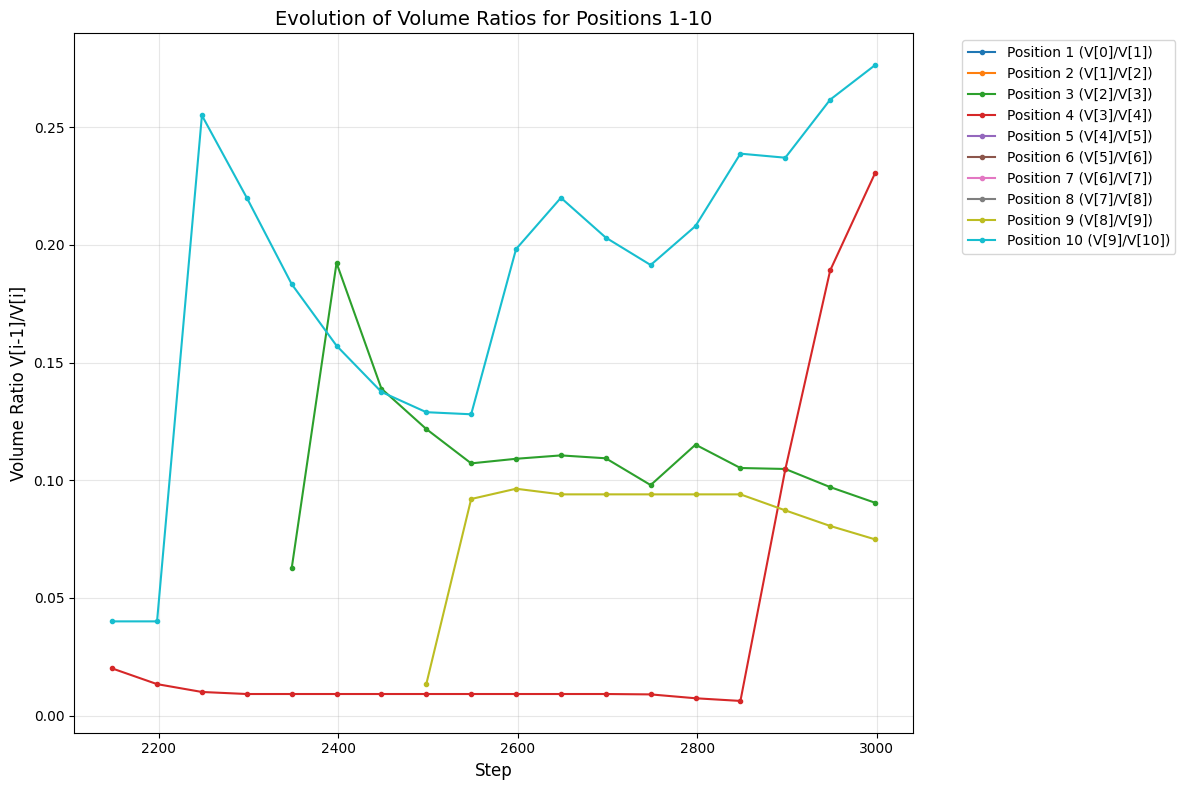


=== Volume of Each Subset Relative to Total Volume ===
V[i]/V_total = Volume of {x: f(x) <= y_i} / Total Parameter Space Volume

Using position 50 as maximum (V_total)

Position   Threshold y_i   V[i]/V_total    Percentage  
------------------------------------------------------------
0          1.000000e-02    N/A             N/A         
1          5.111837e+00    N/A             N/A         
2          1.021367e+01    N/A             N/A         
3          1.531551e+01    N/A             N/A         
4          2.041735e+01    N/A             N/A         
5          2.551918e+01    N/A             N/A         
6          3.062102e+01    N/A             N/A         
7          3.572286e+01    N/A             N/A         
8          4.082469e+01    1.565983e-09    0.0000      %
9          4.592653e+01    2.139192e-08    0.0000      %
10         5.102837e+01    7.872862e-08    0.0000      %
11         5.613020e+01    1.644185e-07    0.0000      %
12         6.123204e+01    6.705829e-

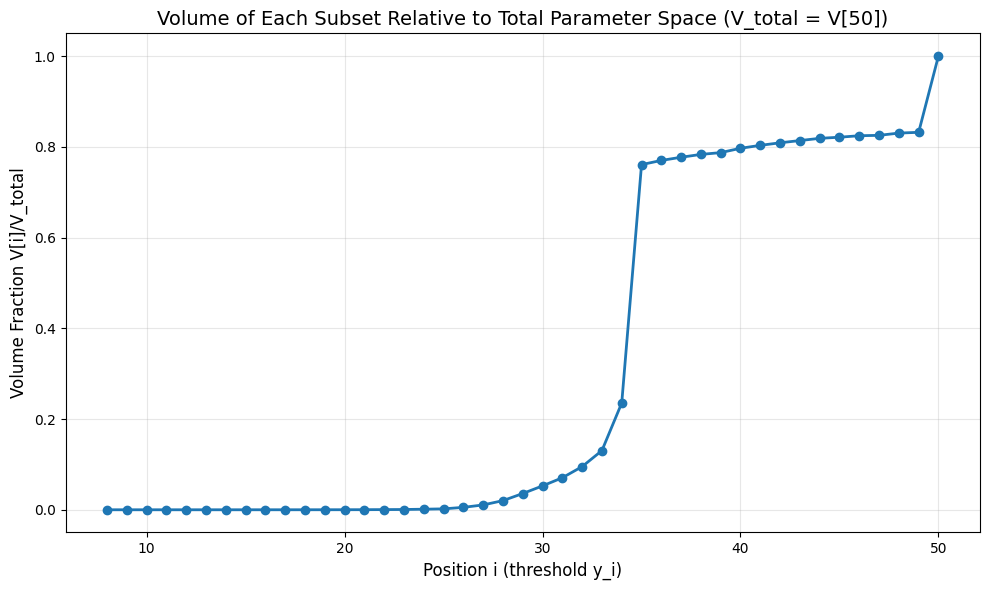

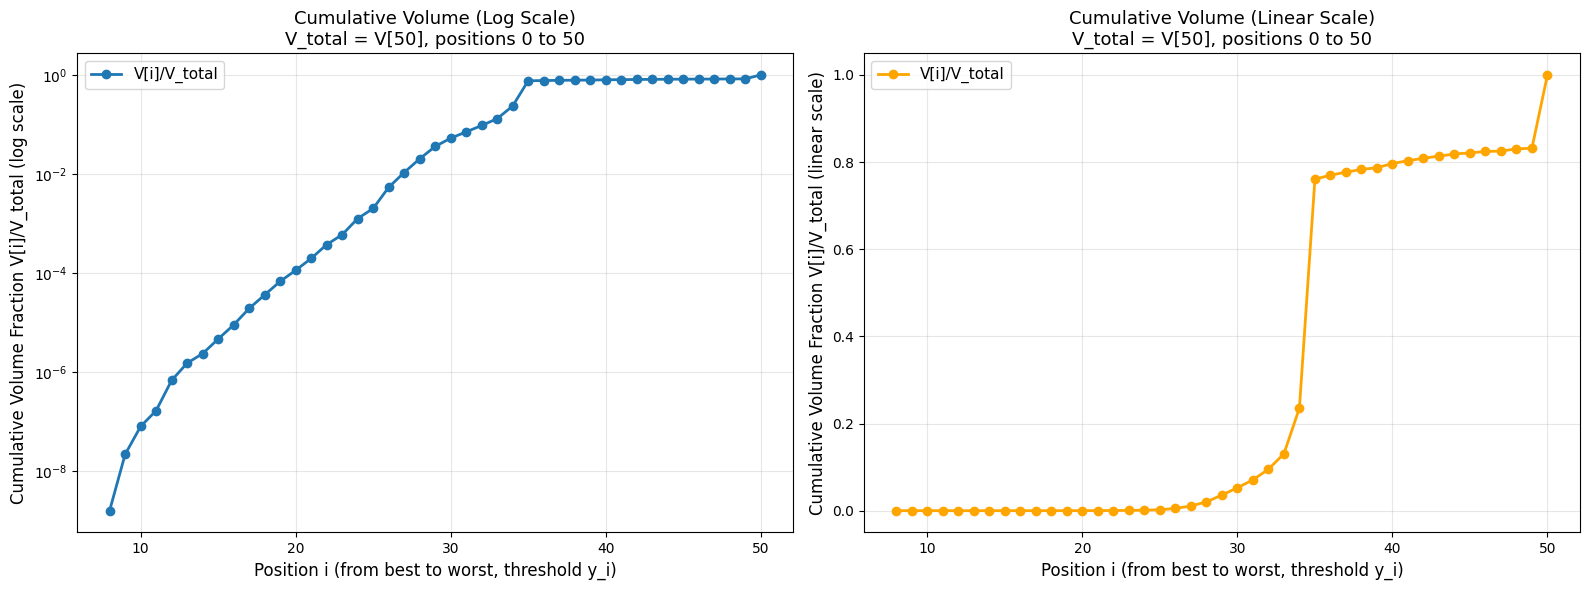

In [ ]:
# ============================================================================
# === PLOT VOLUME RATIO EVOLUTION FOR POSITIONS 1-10 ===
# ============================================================================

if is_burned_in and len(volume_ratio_history) > 0:
    # Extract data for positions 1-10
    positions_to_plot = list(range(1, 11))  # Positions 1-10
    
    plt.figure(figsize=(12, 8))
    
    for pos in positions_to_plot:
        if pos < len(volume_ratio_history[0][1]):
            steps = [item[0] for item in volume_ratio_history]
            ratios = [item[1][pos] if item[1][pos] > 0 else np.nan for item in volume_ratio_history]
            plt.plot(steps, ratios, marker='o', label=f'Position {pos} (V[{pos-1}]/V[{pos}])', markersize=3)
    
    plt.xlabel('Step', fontsize=12)
    plt.ylabel('Volume Ratio V[i-1]/V[i]', fontsize=12)
    plt.title('Evolution of Volume Ratios for Positions 1-10', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================================
# === COMPUTE AND PRINT VOLUME OF EACH SUBSET RELATIVE TO TOTAL VOLUME ===
# ============================================================================

if is_burned_in:
    print("\n=== Volume of Each Subset Relative to Total Volume ===")
    print("V[i]/V_total = Volume of {x: f(x) <= y_i} / Total Parameter Space Volume")
    print()
    
    # Find the maximum position with valid volume ratio data
    max_valid_pos = 0
    for i in range(1, len(volume_ratios)):
        if volume_ratios[i] > 0:
            max_valid_pos = i
    
    print(f"Using position {max_valid_pos} as maximum (V_total)")
    print()
    
    # Compute V[i]/V_total iteratively
    volume_fractions = np.full(N_Vec + 1, np.nan)
    
    # Start from the worst position (max_valid_pos): V[max_valid_pos]/V_total = 1.0
    volume_fractions[max_valid_pos] = 1.0
    
    # Work backwards: compute V[i]/V_total for i from max_valid_pos-1 down to 0
    for i in range(max_valid_pos - 1, -1, -1):
        # V[i]/V_total = product of ratios from i+1 to max_valid_pos
        product = 1.0
        for j in range(i + 1, max_valid_pos + 1):
            if j < len(volume_ratios) and volume_ratios[j] > 0:
                product *= volume_ratios[j]
            else:
                product = np.nan
                break
        volume_fractions[i] = product
    
    # Print results
    print(f"{'Position':<10} {'Threshold y_i':<15} {'V[i]/V_total':<15} {'Percentage':<12}")
    print("-" * 60)
    for i in range(max_valid_pos + 1):
        if not np.isnan(volume_fractions[i]):
            percentage = volume_fractions[i] * 100
            print(f"{i:<10} {bin_thresholds[i]:<15.6e} {volume_fractions[i]:<15.6e} {percentage:<12.4f}%")
        else:
            print(f"{i:<10} {bin_thresholds[i]:<15.6e} {'N/A':<15} {'N/A':<12}")
    
    # Plot volume fractions
    plt.figure(figsize=(10, 6))
    valid_indices = [i for i in range(max_valid_pos + 1) if not np.isnan(volume_fractions[i])]
    valid_fractions = [volume_fractions[i] for i in valid_indices]
    plt.plot(valid_indices, valid_fractions, marker='o', linewidth=2, markersize=6)
    plt.xlabel('Position i (threshold y_i)', fontsize=12)
    plt.ylabel('Volume Fraction V[i]/V_total', fontsize=12)
    plt.title(f'Volume of Each Subset Relative to Total Parameter Space (V_total = V[{max_valid_pos}])', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Cumulative volume plot: side by side log and linear
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    valid_indices = [i for i in range(max_valid_pos + 1) if not np.isnan(volume_fractions[i])]
    valid_fractions = [volume_fractions[i] for i in valid_indices]
    
    # Left plot: Log scale
    ax1.semilogy(valid_indices, valid_fractions, marker='o', linewidth=2, markersize=6, label='V[i]/V_total')
    ax1.set_xlabel('Position i (from best to worst, threshold y_i)', fontsize=12)
    ax1.set_ylabel('Cumulative Volume Fraction V[i]/V_total (log scale)', fontsize=12)
    ax1.set_title(f'Cumulative Volume (Log Scale)\nV_total = V[{max_valid_pos}], positions 0 to {max_valid_pos}', fontsize=13)
    ax1.grid(True, alpha=0.3, which='both')
    ax1.legend(fontsize=11)
    
    # Right plot: Linear scale
    ax2.plot(valid_indices, valid_fractions, marker='o', linewidth=2, markersize=6, label='V[i]/V_total', color='orange')
    ax2.set_xlabel('Position i (from best to worst, threshold y_i)', fontsize=12)
    ax2.set_ylabel('Cumulative Volume Fraction V[i]/V_total (linear scale)', fontsize=12)
    ax2.set_title(f'Cumulative Volume (Linear Scale)\nV_total = V[{max_valid_pos}], positions 0 to {max_valid_pos}', fontsize=13)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)
    
    # Add threshold annotations if not too many points
    if len(valid_indices) <= 20:
        step = max(1, len(valid_indices)//10)
        for idx in valid_indices[::step]:
            frac_idx = valid_indices.index(idx)
            # Log plot annotations
            ax1.annotate(f'y={bin_thresholds[idx]:.1f}', 
                        xy=(idx, valid_fractions[frac_idx]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
            # Linear plot annotations
            ax2.annotate(f'y={bin_thresholds[idx]:.1f}', 
                        xy=(idx, valid_fractions[frac_idx]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
    
    plt.tight_layout()
    plt.show()

Preparing data for visualization...
  Total steps: 3048
  Steps with valid data: 3048
  First valid step: 0
  Best f value trajectory: 3048 points

Computing PCA for trajectory visualization...
✓ PCA complete
  Explained variance ratio: [0.71964397 0.11096891 0.0343768 ]
  Total explained variance: 0.8650
Simulating with first and last parameters...
✓ Simulations complete


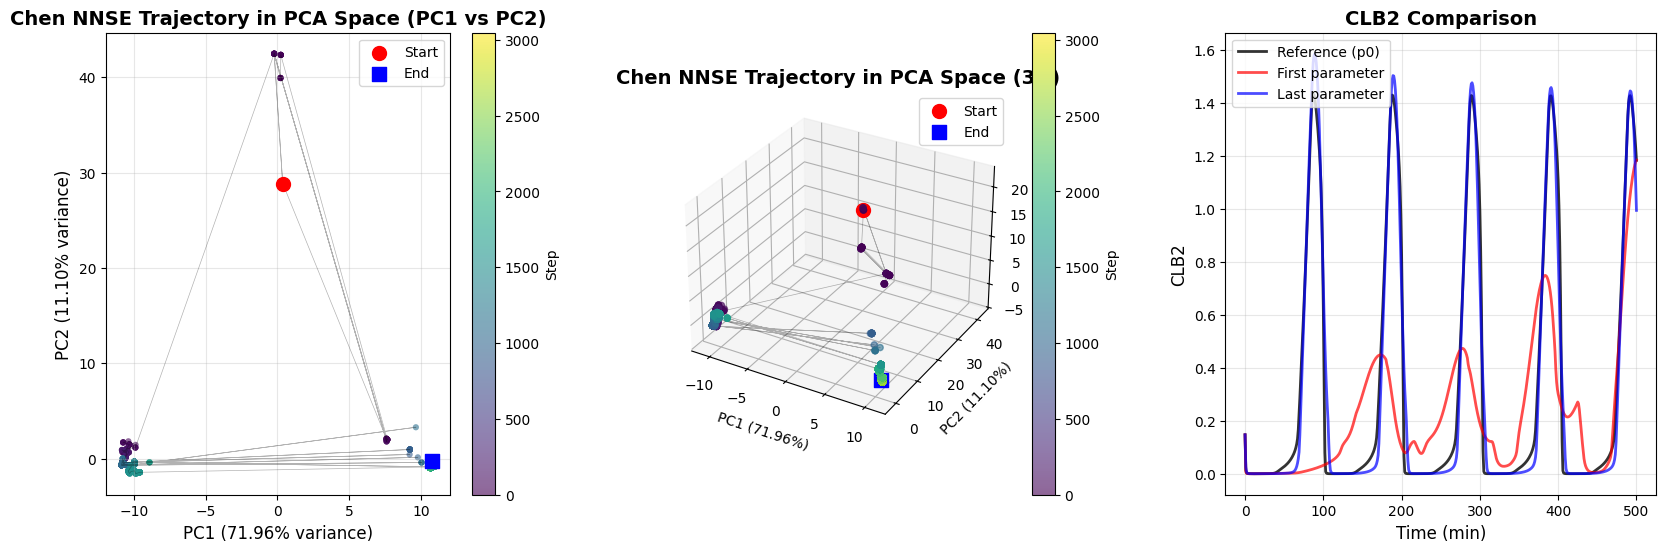


Plotting distribution of squared differences...
  Valid values: 129057/155448
  Mean: 1.254046e+02
  Median: 1.381157e+02
  Min: 3.080088e+00
  Max: 9.716141e+02


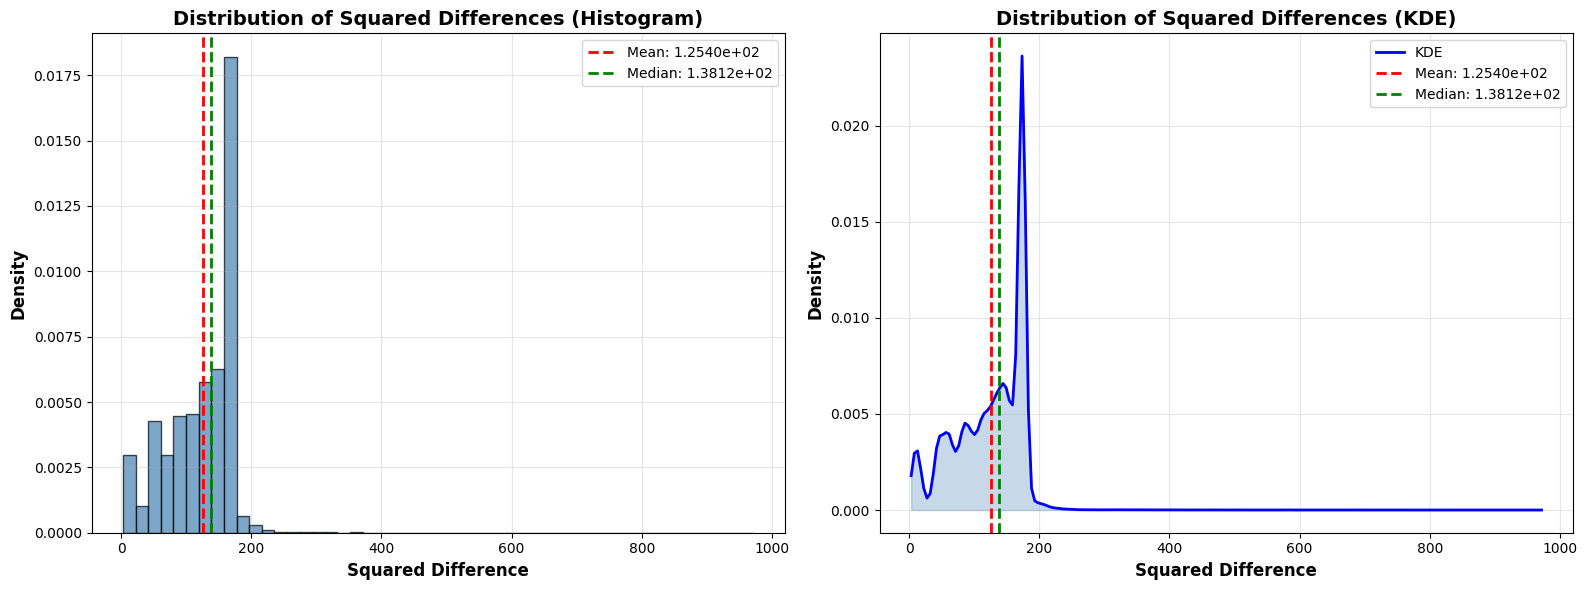

✓ Visualization complete

Saving all figures...
Recreating and saving figures from stored data...
  ✓ Saved: ChenNNSE_figures/01_wildtype_vs_mutants_20260123_133322.png
  ✓ Saved: ChenNNSE_figures/02_best_objective_over_steps_20260123_133322.png
  ✓ Saved: ChenNNSE_figures/03_volume_ratio_evolution_20260123_133322.png
  ✓ Saved: ChenNNSE_figures/04_volume_fractions_20260123_133322.png
  ✓ Saved: ChenNNSE_figures/05_cumulative_volume_20260123_133322.png
  ✓ Saved: ChenNNSE_figures/06_pca_trajectory_and_clb2_20260123_133322.png
  ✓ Saved: ChenNNSE_figures/07_squared_diff_distribution_20260123_133322.png

✓ All figures saved to directory: ChenNNSE_figures/
  Total figures saved: 7


In [ ]:
# ============================================================================
# === VISUALIZATION: PCA TRAJECTORY AND DISTRIBUTIONS ===
# ============================================================================

from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

print("Preparing data for visualization...")

# Extract the best vector at each step
# Since vectors are sorted by f value, find the first non-NaN value (best available)
trajectory = []
squared_diffs = []
step_indices = []  # Keep track of which steps had valid data

for step_idx in range(len(all_X_array)):
    # Find the first non-NaN (best) vector at this step
    for pos_idx in range(n):
        if not np.isnan(all_fX_array[step_idx, pos_idx]):
            trajectory.append(all_X_array[step_idx, pos_idx])
            squared_diffs.append(all_fX_array[step_idx, pos_idx])
            step_indices.append(step_idx)
            break  # Found the best available vector, move to next step

trajectory = np.array(trajectory)
squared_diffs = np.array(squared_diffs)
step_indices = np.array(step_indices)

print(f"  Total steps: {len(all_X_array)}")
print(f"  Steps with valid data: {len(trajectory)}")
print(f"  First valid step: {step_indices[0] if len(step_indices) > 0 else 'None'}")
print(f"  Best f value trajectory: {len(squared_diffs)} points")

# ============================================================================
# === PCA TRAJECTORY PLOT ===
# ============================================================================

print("\nComputing PCA for trajectory visualization...")

# Normalize trajectory for PCA (use standardized parameters)
trajectory_normalized = (trajectory - trajectory.mean(axis=0)) / (trajectory.std(axis=0) + 1e-10)

# Compute PCA
pca = PCA(n_components=min(3, n_params))
trajectory_pca = pca.fit_transform(trajectory_normalized)

print(f"✓ PCA complete")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"  Total explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

# ============================================================================
# === ANALYZE PCA COMPONENT LOADINGS ===
# ============================================================================

print("\n" + "="*80)
print("PCA COMPONENT ANALYSIS: Which parameters drive each PC?")
print("="*80)

# Get the PCA components (loadings)
pc_loadings = pca.components_

# Get parameter names
param_names = kinetic_params

# For each principal component, show top contributing parameters
n_top_params = 10  # Show top 10 parameters for each PC

for pc_idx in range(min(3, pc_loadings.shape[0])):
    print(f"\n{'='*80}")
    print(f"Principal Component {pc_idx + 1} ({pca.explained_variance_ratio_[pc_idx]:.2%} variance)")
    print(f"{'='*80}")
    
    # Get loadings for this PC
    loadings = pc_loadings[pc_idx, :]
    
    # Sort by absolute value (magnitude matters, not sign)
    abs_loadings = np.abs(loadings)
    top_indices = np.argsort(abs_loadings)[::-1][:n_top_params]
    
    # Print table header
    print(f"\n{'Rank':<6} {'Parameter':<30} {'Loading':<12} {'|Loading|':<12}")
    print("-" * 60)
    
    # Print top parameters
    for rank, idx in enumerate(top_indices, 1):
        param_name = param_names[idx] if idx < len(param_names) else f"param_{idx}"
        loading = loadings[idx]
        abs_loading = abs_loadings[idx]
        print(f"{rank:<6} {param_name:<30} {loading:>11.4f} {abs_loading:>11.4f}")
    
    # Calculate how much variance these top parameters explain
    top_loading_squared = np.sum(loadings[top_indices]**2)
    total_loading_squared = np.sum(loadings**2)
    top_contribution = top_loading_squared / total_loading_squared * 100
    
    print(f"\nTop {n_top_params} parameters explain {top_contribution:.1f}% of PC{pc_idx+1} variance")
    
    # Check if it's dominated by one parameter
    if abs_loadings[top_indices[0]] > 0.5:
        dominant_param = param_names[top_indices[0]] if top_indices[0] < len(param_names) else f"param_{top_indices[0]}"
        print(f"⚠️  PC{pc_idx+1} is DOMINATED by single parameter: {dominant_param} (loading = {loadings[top_indices[0]]:.3f})")
    elif abs_loadings[top_indices[0]] < 0.3:
        print(f"✓ PC{pc_idx+1} is a MIXTURE of many parameters (no single dominant direction)")
    else:
        dominant_param = param_names[top_indices[0]] if top_indices[0] < len(param_names) else f"param_{top_indices[0]}"
        print(f"✓ PC{pc_idx+1} is moderately influenced by {dominant_param}")

print(f"\n{'='*80}\n")


# Simulate with first and last parameters for CLB2 comparison
print("Simulating with first and last parameters...")
P_first = trajectory[0]  # Best parameter vector at step 0
P_last = trajectory[-1]  # Best parameter vector at final step

# Simulate with first parameters
rr_first = te.loadSBMLModel(model_path)
reset_model_to_params(rr_first, P_first, kinetic_params, default_values)
t_first, clb2_first = simulate_chen(rr_first, T_END, N_TIME_POINTS)

# Simulate with last parameters
rr_last = te.loadSBMLModel(model_path)
reset_model_to_params(rr_last, P_last, kinetic_params, default_values)
t_last, clb2_last = simulate_chen(rr_last, T_END, N_TIME_POINTS)

print("✓ Simulations complete")

# Create figure with 3 subplots
fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# Plot 2D PCA trajectory
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(trajectory_pca[:, 0], trajectory_pca[:, 1], 
                     c=range(len(trajectory_pca)), cmap='viridis', 
                     s=20, alpha=0.6, edgecolors='none')
ax1.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], 'k-', alpha=0.3, linewidth=0.5)
ax1.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], 
           color='red', s=100, marker='o', label='Start', zorder=5)
ax1.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], 
           color='blue', s=100, marker='s', label='End', zorder=5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax1.set_title('Chen NNSE Trajectory in PCA Space (PC1 vs PC2)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Step')

# Second subplot: 3D plot or squared difference over time
if trajectory_pca.shape[1] >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    ax2 = fig.add_subplot(gs[0, 1], projection='3d')
    scatter2 = ax2.scatter(trajectory_pca[:, 0], trajectory_pca[:, 1], trajectory_pca[:, 2],
                         c=range(len(trajectory_pca)), cmap='viridis', s=20, alpha=0.6)
    ax2.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], trajectory_pca[:, 2], 
            'k-', alpha=0.3, linewidth=0.5)
    ax2.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], trajectory_pca[0, 2],
               color='red', s=100, marker='o', label='Start')
    ax2.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], trajectory_pca[-1, 2],
               color='blue', s=100, marker='s', label='End')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=10)
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=10)
    ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})', fontsize=10)
    ax2.set_title('Chen NNSE Trajectory in PCA Space (3D)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    plt.colorbar(scatter2, ax=ax2, label='Step')
else:
    # If only 2 components, show squared difference over time
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(range(len(squared_diffs)), squared_diffs, 'b-', linewidth=1, alpha=0.7)
    ax2.set_xlabel('Step', fontsize=12)
    ax2.set_ylabel('Squared Difference', fontsize=12)
    ax2.set_title('Best Squared Difference Over Time', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

# Third subplot: CLB2 comparison
ax3 = fig.add_subplot(gs[0, 2])
if t0_ref is not None and not isinstance(t0_ref, str):
    ax3.plot(t0_ref, clb2_0_ref, 'k-', lw=2, label='Reference (p0)', alpha=0.8)
if t_first is not None and not isinstance(t_first, str):
    ax3.plot(t_first, clb2_first, 'r-', lw=2, label='First parameter', alpha=0.7)
if t_last is not None and not isinstance(t_last, str):
    ax3.plot(t_last, clb2_last, 'b-', lw=2, label='Last parameter', alpha=0.7)
ax3.set_xlabel('Time (min)', fontsize=12)
ax3.set_ylabel('CLB2', fontsize=12)
ax3.set_title('CLB2 Comparison', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# === DISTRIBUTION OF SQUARED DIFFERENCES ===
# ============================================================================

print("\nPlotting distribution of squared differences...")

# For distribution, use all squared differences from all vectors at all steps
squared_diffs_all = all_fX_array.flatten()  # All function values from all vectors

# Filter out infinite values
valid_mask = np.isfinite(squared_diffs_all)
squared_diffs_valid = squared_diffs_all[valid_mask]

print(f"  Valid values: {np.sum(valid_mask)}/{len(squared_diffs_all)}")
print(f"  Mean: {np.mean(squared_diffs_valid):.6e}")
print(f"  Median: {np.median(squared_diffs_valid):.6e}")
print(f"  Min: {np.min(squared_diffs_valid):.6e}")
print(f"  Max: {np.max(squared_diffs_valid):.6e}")

# Create distribution plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with linear bins
ax1 = axes[0]
n_bins_hist = 50
counts, bins_hist, patches = ax1.hist(squared_diffs_valid, bins=n_bins_hist, 
                                      edgecolor='black', alpha=0.7, color='steelblue',
                                      density=True)
ax1.axvline(np.mean(squared_diffs_valid), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {np.mean(squared_diffs_valid):.4e}')
ax1.axvline(np.median(squared_diffs_valid), color='green', linestyle='--', 
           linewidth=2, label=f'Median: {np.median(squared_diffs_valid):.4e}')
ax1.set_xlabel('Squared Difference', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Squared Differences (Histogram)', 
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Kernel density estimate (KDE) with linear scale
ax2 = axes[1]
if len(squared_diffs_valid) > 1:
    kde = gaussian_kde(squared_diffs_valid)
    x_kde = np.linspace(squared_diffs_valid.min(), squared_diffs_valid.max(), 200)
    density = kde(x_kde)
    ax2.plot(x_kde, density, 'b-', linewidth=2, label='KDE')
    ax2.fill_between(x_kde, 0, density, alpha=0.3, color='steelblue')
    ax2.axvline(np.mean(squared_diffs_valid), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(squared_diffs_valid):.4e}')
    ax2.axvline(np.median(squared_diffs_valid), color='green', linestyle='--', 
               linewidth=2, label=f'Median: {np.median(squared_diffs_valid):.4e}')
    ax2.set_xlabel('Squared Difference', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax2.set_title('Distribution of Squared Differences (KDE)', 
                 fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Not enough data for KDE', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Distribution of Squared Differences (KDE)', 
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

# ============================================================================
# === SAVE ALL FIGURES ===
# ============================================================================

print("\nSaving all figures...")

# Create output directory for figures
output_dir = "ChenNNSE_figures"
os.makedirs(output_dir, exist_ok=True)

# Get timestamp for unique filenames
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# List to track saved files
saved_files = []

# Note: plt.show() closes figures, so we need to recreate them or use saved references
# We'll recreate key figures from the stored data

print("Recreating and saving figures from stored data...")

# Figure 1: Wildtype vs Random Mutants (if data exists)
if len(random_clb2_traces) > 0:
    fig1, ax = plt.subplots(figsize=(12, 6))
    ax.plot(t0_ref, clb2_0_ref, 'k-', linewidth=3, label='Wildtype (p₀)', zorder=10)
    colors = plt.cm.tab10(np.linspace(0, 1, len(random_clb2_traces)))
    for idx, ((t_rand, clb2_rand), f_val) in enumerate(zip(random_clb2_traces, random_f_values)):
        ax.plot(t_rand, clb2_rand, color=colors[idx], linewidth=2, alpha=0.7,
                label=f'Mutant {idx+1} (f={f_val:.1e})')
    ax.set_xlabel('Time (minutes)', fontsize=14, fontweight='bold')
    ax.set_ylabel('CLB2 Concentration', fontsize=14, fontweight='bold')
    ax.set_title('Chen Cell Cycle Model: Wildtype vs Random Mutants\nCLB2 Dynamics Over Time', 
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, T_END])
    plt.tight_layout()
    filepath = os.path.join(output_dir, f"01_wildtype_vs_mutants_{timestamp}.png")
    fig1.savefig(filepath, dpi=300, bbox_inches='tight')
    saved_files.append(filepath)
    print(f"  ✓ Saved: {filepath}")
    plt.close(fig1)

# Figure 2: Best objective over steps
fig2 = plt.figure(figsize=(8,4))
plt.plot(best_vals, label='best f')
plt.yscale('log')
plt.xlabel('Step')
plt.ylabel('Best objective (log)')
plt.title('Chen NNSE: Best objective over steps')
plt.legend()
plt.grid(True, alpha=0.3)
filepath = os.path.join(output_dir, f"02_best_objective_over_steps_{timestamp}.png")
fig2.savefig(filepath, dpi=300, bbox_inches='tight')
saved_files.append(filepath)
print(f"  ✓ Saved: {filepath}")
plt.close(fig2)

# Figure 3: Volume ratio evolution (if burned in)
if is_burned_in and len(volume_ratio_history) > 0:
    positions_to_plot = list(range(1, 11))
    fig3 = plt.figure(figsize=(12, 8))
    for pos in positions_to_plot:
        if pos < len(volume_ratio_history[0][1]):
            steps = [item[0] for item in volume_ratio_history]
            ratios = [item[1][pos] if item[1][pos] > 0 else np.nan for item in volume_ratio_history]
            plt.plot(steps, ratios, marker='o', label=f'Position {pos} (V[{pos-1}]/V[{pos}])', markersize=3)
    plt.xlabel('Step', fontsize=12)
    plt.ylabel('Volume Ratio V[i-1]/V[i]', fontsize=12)
    plt.title('Evolution of Volume Ratios for Positions 1-10', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    filepath = os.path.join(output_dir, f"03_volume_ratio_evolution_{timestamp}.png")
    fig3.savefig(filepath, dpi=300, bbox_inches='tight')
    saved_files.append(filepath)
    print(f"  ✓ Saved: {filepath}")
    plt.close(fig3)

# Figure 4: Volume fractions
if is_burned_in:
    fig4 = plt.figure(figsize=(10, 6))
    valid_indices = [i for i in range(max_valid_pos + 1) if not np.isnan(volume_fractions[i])]
    valid_fractions = [volume_fractions[i] for i in valid_indices]
    plt.plot(valid_indices, valid_fractions, marker='o', linewidth=2, markersize=6)
    plt.xlabel('Position i (threshold y_i)', fontsize=12)
    plt.ylabel('Volume Fraction V[i]/V_total', fontsize=12)
    plt.title(f'Volume of Each Subset Relative to Total Parameter Space (V_total = V[{max_valid_pos}])', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    filepath = os.path.join(output_dir, f"04_volume_fractions_{timestamp}.png")
    fig4.savefig(filepath, dpi=300, bbox_inches='tight')
    saved_files.append(filepath)
    print(f"  ✓ Saved: {filepath}")
    plt.close(fig4)

# Figure 5: Cumulative volume (log and linear)
if is_burned_in:
    fig5, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    valid_indices = [i for i in range(max_valid_pos + 1) if not np.isnan(volume_fractions[i])]
    valid_fractions = [volume_fractions[i] for i in valid_indices]
    
    ax1.semilogy(valid_indices, valid_fractions, marker='o', linewidth=2, markersize=6, label='V[i]/V_total')
    ax1.set_xlabel('Position i (from best to worst, threshold y_i)', fontsize=12)
    ax1.set_ylabel('Cumulative Volume Fraction V[i]/V_total (log scale)', fontsize=12)
    ax1.set_title(f'Cumulative Volume (Log Scale)\nV_total = V[{max_valid_pos}], positions 0 to {max_valid_pos}', fontsize=13)
    ax1.grid(True, alpha=0.3, which='both')
    ax1.legend(fontsize=11)
    
    ax2.plot(valid_indices, valid_fractions, marker='o', linewidth=2, markersize=6, label='V[i]/V_total', color='orange')
    ax2.set_xlabel('Position i (from best to worst, threshold y_i)', fontsize=12)
    ax2.set_ylabel('Cumulative Volume Fraction V[i]/V_total (linear scale)', fontsize=12)
    ax2.set_title(f'Cumulative Volume (Linear Scale)\nV_total = V[{max_valid_pos}], positions 0 to {max_valid_pos}', fontsize=13)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)
    
    plt.tight_layout()
    filepath = os.path.join(output_dir, f"05_cumulative_volume_{timestamp}.png")
    fig5.savefig(filepath, dpi=300, bbox_inches='tight')
    saved_files.append(filepath)
    print(f"  ✓ Saved: {filepath}")
    plt.close(fig5)

# Figure 6: PCA trajectory and CLB2 comparison
fig6 = plt.figure(figsize=(20, 6))
gs = fig6.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

ax1 = fig6.add_subplot(gs[0, 0])
scatter = ax1.scatter(trajectory_pca[:, 0], trajectory_pca[:, 1], 
                     c=range(len(trajectory_pca)), cmap='viridis', 
                     s=20, alpha=0.6, edgecolors='none')
ax1.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], 'k-', alpha=0.3, linewidth=0.5)
ax1.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], 
           color='red', s=100, marker='o', label='Start', zorder=5)
ax1.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], 
           color='blue', s=100, marker='s', label='End', zorder=5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax1.set_title('Chen NNSE Trajectory in PCA Space (PC1 vs PC2)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Step')

if trajectory_pca.shape[1] >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    ax2 = fig6.add_subplot(gs[0, 1], projection='3d')
    scatter2 = ax2.scatter(trajectory_pca[:, 0], trajectory_pca[:, 1], trajectory_pca[:, 2],
                         c=range(len(trajectory_pca)), cmap='viridis', s=20, alpha=0.6)
    ax2.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], trajectory_pca[:, 2], 
            'k-', alpha=0.3, linewidth=0.5)
    ax2.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], trajectory_pca[0, 2],
               color='red', s=100, marker='o', label='Start')
    ax2.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], trajectory_pca[-1, 2],
               color='blue', s=100, marker='s', label='End')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=10)
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=10)
    ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})', fontsize=10)
    ax2.set_title('Chen NNSE Trajectory in PCA Space (3D)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    plt.colorbar(scatter2, ax=ax2, label='Step')
else:
    ax2 = fig6.add_subplot(gs[0, 1])
    ax2.plot(range(len(squared_diffs)), squared_diffs, 'b-', linewidth=1, alpha=0.7)
    ax2.set_xlabel('Step', fontsize=12)
    ax2.set_ylabel('Squared Difference', fontsize=12)
    ax2.set_title('Best Squared Difference Over Time', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

ax3 = fig6.add_subplot(gs[0, 2])
if t0_ref is not None and not isinstance(t0_ref, str):
    ax3.plot(t0_ref, clb2_0_ref, 'k-', lw=2, label='Reference (p0)', alpha=0.8)
if t_first is not None and not isinstance(t_first, str):
    ax3.plot(t_first, clb2_first, 'r-', lw=2, label='First parameter', alpha=0.7)
if t_last is not None and not isinstance(t_last, str):
    ax3.plot(t_last, clb2_last, 'b-', lw=2, label='Last parameter', alpha=0.7)
ax3.set_xlabel('Time (min)', fontsize=12)
ax3.set_ylabel('CLB2', fontsize=12)
ax3.set_title('CLB2 Comparison', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
filepath = os.path.join(output_dir, f"06_pca_trajectory_and_clb2_{timestamp}.png")
fig6.savefig(filepath, dpi=300, bbox_inches='tight')
saved_files.append(filepath)
print(f"  ✓ Saved: {filepath}")
plt.close(fig6)

# Figure 7: Distribution of squared differences
fig7, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
n_bins_hist = 50
counts, bins_hist, patches = ax1.hist(squared_diffs_valid, bins=n_bins_hist, 
                                      edgecolor='black', alpha=0.7, color='steelblue',
                                      density=True)
ax1.axvline(np.mean(squared_diffs_valid), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {np.mean(squared_diffs_valid):.4e}')
ax1.axvline(np.median(squared_diffs_valid), color='green', linestyle='--', 
           linewidth=2, label=f'Median: {np.median(squared_diffs_valid):.4e}')
ax1.set_xlabel('Squared Difference', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Squared Differences (Histogram)', 
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
if len(squared_diffs_valid) > 1:
    kde = gaussian_kde(squared_diffs_valid)
    x_kde = np.linspace(squared_diffs_valid.min(), squared_diffs_valid.max(), 200)
    density = kde(x_kde)
    ax2.plot(x_kde, density, 'b-', linewidth=2, label='KDE')
    ax2.fill_between(x_kde, 0, density, alpha=0.3, color='steelblue')
    ax2.axvline(np.mean(squared_diffs_valid), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(squared_diffs_valid):.4e}')
    ax2.axvline(np.median(squared_diffs_valid), color='green', linestyle='--', 
               linewidth=2, label=f'Median: {np.median(squared_diffs_valid):.4e}')
    ax2.set_xlabel('Squared Difference', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax2.set_title('Distribution of Squared Differences (KDE)', 
                 fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Not enough data for KDE', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Distribution of Squared Differences (KDE)', 
                 fontsize=14, fontweight='bold')

plt.tight_layout()
filepath = os.path.join(output_dir, f"07_squared_diff_distribution_{timestamp}.png")
fig7.savefig(filepath, dpi=300, bbox_inches='tight')
saved_files.append(filepath)
print(f"  ✓ Saved: {filepath}")
plt.close(fig7)

print(f"\n✓ All figures saved to directory: {output_dir}/")
print(f"  Total figures saved: {len(saved_files)}")

In [ ]:
# ============================================================================
# === JACKKNIFE STABILITY DIAGNOSTIC OVER INDEPENDENT FULL RUNS ===
# ============================================================================
# Treat each *full* simulation run (different seed) as one observation.
# We do NOT jackknife over internal steps/states.

import contextlib
import io
from stability_jackknife import run_jackknife


def run_volume_ratio_simulation(seed: int, *, verbose: bool = False) -> np.ndarray:
    """Run one full simulation with a given seed and return final volume ratios.

    Returns
    -------
    ratios : np.ndarray
        Shape (N_Vec,), corresponding to V[i-1]/V[i] for i=1..N_Vec.
        (Index 0 is omitted because it's unused in the notebook code.)

    Notes
    -----
    - Uses the existing simulation logic (ChenNNSEFunc + swap counting) unchanged.
    - Re-initializes all per-run state so runs are independent.
    """
    np.random.seed(int(seed))

    def _run() -> np.ndarray:
        n = N_Vec + 1  # FIXED: Must be N_Vec + 1 to match main loop

        # Create worker pool for this jackknife run (same as main loop)
        jk_pool = Pool(processes=mp.cpu_count())

        # Initialize population (same logic as the main simulation cell)
        X_list = [None] * n
        fX_list = [None] * n

        # === NEW INITIALIZATION STRATEGY (same as main loop) ===
        # Generate random points and place them in appropriate bins until we have 10 filled positions
        max_init_attempts = 1000
        target_filled = 10
        successful_placements = 0

        for attempt in range(max_init_attempts):
            # Generate random parameter vector in hypercube
            u_random = np.random.uniform(0, 1, size=n_params)
            xi = 2.0 * p0_vec * u_random
            fxi = sim(xi)
            
            # Find the minimum non-empty bin with threshold y > fxi
            best_bin = None
            for pos in range(n):
                if fxi <= bin_thresholds[pos]:  # This bin's threshold is higher than our value
                    if X_list[pos] is None:  # This bin is empty, we can place here
                        best_bin = pos
                        break
                    # If bin is already filled, continue to find next empty bin
            
            # Place the parameter set in the best bin if found
            if best_bin is not None:
                X_list[best_bin] = xi
                fX_list[best_bin] = fxi
                successful_placements += 1
                
                if successful_placements >= target_filled:
                    break
            # If no suitable bin found, try next random point (continue loop)
                    X_list[idx] = xi
                    fX_list[idx] = fxi
                    break

        BURN_IN = int(0.5 * N_STEPS)
        swap_count = np.zeros(N_Vec + 1)
        total_opportunities = np.zeros(N_Vec + 1)
        is_burned_in = False

        for step in range(N_STEPS):
            # Use parallel mode with worker pool (same as main loop)
            X_list, fX_list, _fX_mutated, swaps = ChenNNSEFunc(X_list, fX_list, pool=jk_pool)

            if step >= BURN_IN:
                if not is_burned_in:
                    swap_count[:] = 0
                    total_opportunities[:] = 0
                    is_burned_in = True

                swap_set = set(swaps)
                for i in range(1, len(fX_list)):
                    if fX_list[i] is not None and fX_list[i - 1] is not None:
                        total_opportunities[i] += 1
                        if (i, i - 1) in swap_set:
                            swap_count[i] += 1

        if not is_burned_in:
            raise RuntimeError("Burn-in was never reached; increase N_STEPS.")

        volume_ratios = np.zeros(N_Vec + 1)
        for i in range(1, len(swap_count)):
            if total_opportunities[i] > 0:
                volume_ratios[i] = swap_count[i] / total_opportunities[i]
            else:
                volume_ratios[i] = np.nan

        # Close worker pool for this run
        jk_pool.close()
        jk_pool.join()

        return volume_ratios[1:].copy()

    if verbose:
        return _run()

    # Silence prints from lower-level code during repeated runs
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        return _run()


# --- Configure jackknife runs ---
N_RUNS = 5
SEED0 = 0

# Run jackknife simulations SEQUENTIALLY (one at a time)
# Each run uses parallel workers internally (same as main loop)
print(f"Running {N_RUNS} jackknife simulations sequentially...")
print(f"Each run uses {mp.cpu_count()} cores for parallel speedup\n")

start_all = time.time()
seeds = []
runs = []

for i in range(N_RUNS):
    seed = SEED0 + i
    print(f"  Starting run {i+1}/{N_RUNS} (seed={seed})...")
    run_start = time.time()
    
    ratios = run_volume_ratio_simulation(seed, verbose=False)
    
    run_time = time.time() - run_start
    elapsed_total = time.time() - start_all
    remaining = N_RUNS - (i + 1)
    avg_per_run = elapsed_total / (i + 1)
    eta = remaining * avg_per_run
    
    print(f"  ✓ Run {i+1}/{N_RUNS} complete in {run_time/60:.1f} min | "
          f"Total elapsed: {elapsed_total/60:.1f} min | ETA: {eta/60:.1f} min\n")
    
    seeds.append(seed)
    runs.append(ratios)

runs = np.array(runs)

# Compute jackknife statistics manually
from collections import namedtuple
JKResult = namedtuple('JKResult', ['names', 'theta_hat', 'bias', 'se', 'rel_bias', 'rel_se', 
                                     'ok_rel_bias', 'ok_rel_se', 'rel_bias_threshold', 'rel_se_threshold'])

names = [f"V[{i-1}]/V[{i}]" for i in range(1, N_Vec + 1)]
theta_hat = np.nanmean(runs, axis=0)
n_runs = len(runs)

# Jackknife estimates
jackknife_estimates = np.zeros((n_runs, runs.shape[1]))
for i in range(n_runs):
    leave_one_out = np.delete(runs, i, axis=0)
    jackknife_estimates[i] = np.nanmean(leave_one_out, axis=0)

bias = (n_runs - 1) * (np.nanmean(jackknife_estimates, axis=0) - theta_hat)
se = np.sqrt((n_runs - 1) * np.nanmean((jackknife_estimates - theta_hat)**2, axis=0))

rel_bias = np.abs(bias / theta_hat)
rel_se = se / np.abs(theta_hat)

ok_rel_bias = rel_bias < 0.05
ok_rel_se = rel_se < 0.05

jk = JKResult(names, theta_hat, bias, se, rel_bias, rel_se, ok_rel_bias, ok_rel_se, 0.05, 0.05)

wall_time = time.time() - start_all

print(f"\nJackknife over {len(seeds)} independent full runs")
print(f"Seeds: {seeds[:5]}...{seeds[-5:]}")
print(f"Timing: total={wall_time:.1f}s ({wall_time/60:.1f} min)")

# Compact report: show first few ratios
k_show = min(8, len(jk.names))
for j in range(k_show):
    name = jk.names[j]
    th = jk.theta_hat[j]
    bias = jk.bias[j]
    se = jk.se[j]
    print(
        f"{name:<12}  theta_hat={th: .6g}  bias={bias: .3g}  se={se: .3g}  "
        f"rel_bias={jk.rel_bias[j]:.3g}  rel_se={jk.rel_se[j]:.3g}  "
        f"OK(bias)={bool(jk.ok_rel_bias[j])}  OK(se)={bool(jk.ok_rel_se[j])}"
    )

n_ok_bias = int(np.sum(jk.ok_rel_bias))
n_ok_se = int(np.sum(jk.ok_rel_se))
print(
    f"\nSummary: OK rel-bias for {n_ok_bias}/{len(jk.names)} stats, "
    f"OK rel-SE for {n_ok_se}/{len(jk.names)} stats "
    f"(thresholds: {jk.rel_bias_threshold}, {jk.rel_se_threshold})"
)

Running 5 jackknife simulations sequentially...
Each run uses 12 cores for parallel speedup

  Starting run 1/5 (seed=0)...
  ✓ Run 1/5 complete in 10.1 min | Total elapsed: 10.1 min | ETA: 40.6 min

  Starting run 2/5 (seed=1)...
  ✓ Run 2/5 complete in 12.3 min | Total elapsed: 22.5 min | ETA: 33.7 min

  Starting run 3/5 (seed=2)...
  ✓ Run 3/5 complete in 12.9 min | Total elapsed: 35.4 min | ETA: 23.6 min

  Starting run 4/5 (seed=3)...
  ✓ Run 4/5 complete in 12.4 min | Total elapsed: 47.8 min | ETA: 12.0 min

  Starting run 5/5 (seed=4)...
  ✓ Run 5/5 complete in 12.4 min | Total elapsed: 60.2 min | ETA: 0.0 min


Jackknife over 5 independent full runs
Seeds: [0, 1, 2, 3, 4]...[0, 1, 2, 3, 4]
Timing: total=3610.9s (60.2 min)
V[0]/V[1]     theta_hat= nan  bias= nan  se= nan  rel_bias=nan  rel_se=nan  OK(bias)=False  OK(se)=False
V[1]/V[2]     theta_hat= 0.0305887  bias= 0  se= 0.0131  rel_bias=0  rel_se=0.427  OK(bias)=True  OK(se)=False
V[2]/V[3]     theta_hat= 0.195939  bias= 0 

Visualizing jackknife results...
Data: 5 runs × 50 volume ratios



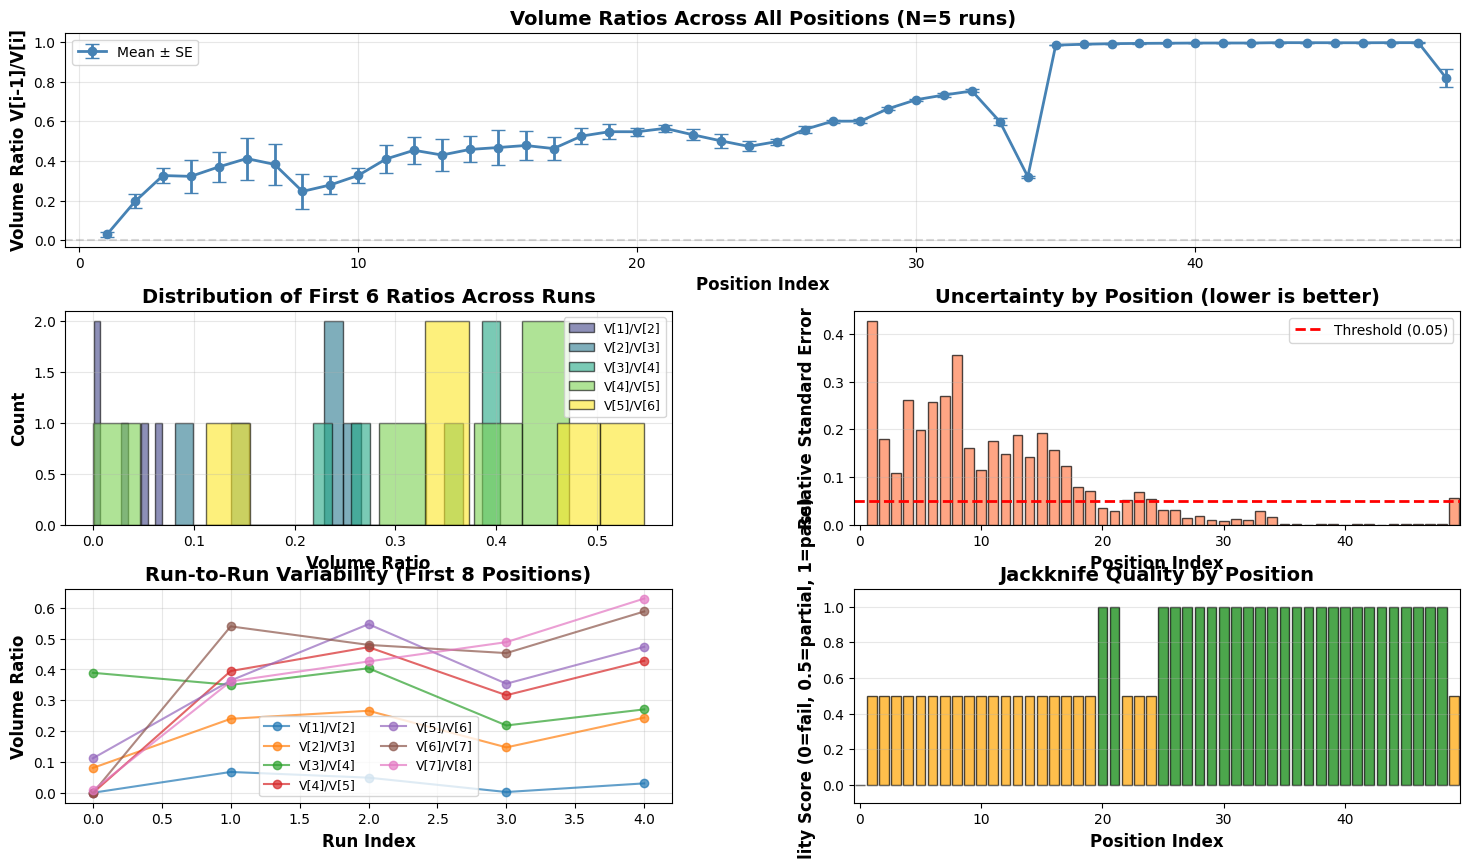


JACKKNIFE SUMMARY STATISTICS
Total runs: 5
Positions analyzed: 50
Passed bias check: 49/50
Passed SE check: 26/50

Mean volume ratio: 0.6224
Median SE: 0.0168
Mean relative SE: 0.0834

Positions with highest uncertainty (top 5 by rel_se):
  V[0]/V[1]: rel_se = nan, theta_hat = nan
  V[1]/V[2]: rel_se = 0.4272, theta_hat = 0.0306
  V[8]/V[9]: rel_se = 0.3569, theta_hat = 0.2466
  V[7]/V[8]: rel_se = 0.2706, theta_hat = 0.3828
  V[4]/V[5]: rel_se = 0.2622, theta_hat = 0.3224

✓ Jackknife visualization complete


In [ ]:
# ============================================================================
# === JACKKNIFE RESULTS VISUALIZATION ===
# ============================================================================

import matplotlib.pyplot as plt

print("Visualizing jackknife results...")
print(f"Data: {len(runs)} runs × {runs.shape[1]} volume ratios\n")

# Create figure with multiple subplots
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Plot all volume ratios with error bars
ax1 = fig.add_subplot(gs[0, :])
positions = np.arange(len(jk.theta_hat))
ax1.errorbar(positions, jk.theta_hat, yerr=jk.se, fmt='o-', capsize=5, 
             markersize=6, linewidth=2, color='steelblue', label='Mean ± SE')
ax1.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax1.set_xlabel('Position Index', fontsize=12, fontweight='bold')
ax1.set_ylabel('Volume Ratio V[i-1]/V[i]', fontsize=12, fontweight='bold')
ax1.set_title(f'Volume Ratios Across All Positions (N={N_RUNS} runs)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_xlim(-0.5, len(positions) - 0.5)

# 2. Distribution of ratios for selected positions (first 6)
ax2 = fig.add_subplot(gs[1, 0])
n_show = min(6, runs.shape[1])
colors = plt.cm.viridis(np.linspace(0, 1, n_show))
for i in range(n_show):
    ratios_i = runs[:, i]
    valid_ratios = ratios_i[~np.isnan(ratios_i)]
    if len(valid_ratios) > 0:
        ax2.hist(valid_ratios, bins=10, alpha=0.6, label=f'V[{i}]/V[{i+1}]', 
                color=colors[i], edgecolor='black')
ax2.set_xlabel('Volume Ratio', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title(f'Distribution of First {n_show} Ratios Across Runs', 
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Relative standard error by position
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(positions, jk.rel_se, color='coral', edgecolor='black', alpha=0.7)
ax3.axhline(0.05, color='red', linestyle='--', linewidth=2, label='Threshold (0.05)')
ax3.set_xlabel('Position Index', fontsize=12, fontweight='bold')
ax3.set_ylabel('Relative Standard Error', fontsize=12, fontweight='bold')
ax3.set_title('Uncertainty by Position (lower is better)', 
              fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xlim(-0.5, len(positions) - 0.5)

# 4. Run-to-run variability (show all runs for selected positions)
ax4 = fig.add_subplot(gs[2, 0])
n_show_runs = min(8, runs.shape[1])
for i in range(n_show_runs):
    ratios_i = runs[:, i]
    valid_mask = ~np.isnan(ratios_i)
    run_indices = np.arange(len(ratios_i))[valid_mask]
    valid_ratios = ratios_i[valid_mask]
    if len(valid_ratios) > 0:
        ax4.plot(run_indices, valid_ratios, 'o-', markersize=6, 
                label=f'V[{i}]/V[{i+1}]', alpha=0.7)
ax4.set_xlabel('Run Index', fontsize=12, fontweight='bold')
ax4.set_ylabel('Volume Ratio', fontsize=12, fontweight='bold')
ax4.set_title(f'Run-to-Run Variability (First {n_show_runs} Positions)', 
              fontsize=14, fontweight='bold')
ax4.legend(fontsize=9, ncol=2)
ax4.grid(True, alpha=0.3)

# 5. Quality check: show which positions passed/failed
ax5 = fig.add_subplot(gs[2, 1])
quality_scores = (jk.ok_rel_bias.astype(int) + jk.ok_rel_se.astype(int)) / 2
colors_qual = ['red' if q < 0.5 else 'orange' if q < 1 else 'green' for q in quality_scores]
ax5.bar(positions, quality_scores, color=colors_qual, edgecolor='black', alpha=0.7)
ax5.set_xlabel('Position Index', fontsize=12, fontweight='bold')
ax5.set_ylabel('Quality Score (0=fail, 0.5=partial, 1=pass)', fontsize=12, fontweight='bold')
ax5.set_title('Jackknife Quality by Position', fontsize=14, fontweight='bold')
ax5.set_ylim(-0.1, 1.1)
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_xlim(-0.5, len(positions) - 0.5)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n{'='*60}")
print(f"JACKKNIFE SUMMARY STATISTICS")
print(f"{'='*60}")
print(f"Total runs: {N_RUNS}")
print(f"Positions analyzed: {len(jk.names)}")
print(f"Passed bias check: {np.sum(jk.ok_rel_bias)}/{len(jk.names)}")
print(f"Passed SE check: {np.sum(jk.ok_rel_se)}/{len(jk.names)}")
print(f"\nMean volume ratio: {np.nanmean(jk.theta_hat):.4f}")
print(f"Median SE: {np.nanmedian(jk.se):.4f}")
print(f"Mean relative SE: {np.nanmean(jk.rel_se):.4f}")
print(f"\nPositions with highest uncertainty (top 5 by rel_se):")
worst_se_idx = np.argsort(jk.rel_se)[-5:][::-1]
for idx in worst_se_idx:
    print(f"  {jk.names[idx]}: rel_se = {jk.rel_se[idx]:.4f}, theta_hat = {jk.theta_hat[idx]:.4f}")

print(f"\n✓ Jackknife visualization complete")

In [ ]:
# === SAVE NEUTRAL COORDINATES FOR DOWNSTREAM ANALYSIS ===
# This cell intentionally avoids saving notebook-local classes such as JKResult.
# It writes a portable .npz plus a small .json summary that later scripts can load.

import json
import numpy as np
from datetime import datetime
from pathlib import Path

output_dir = Path("ChenNNSE_results")
output_dir.mkdir(exist_ok=True)

# Define the neutral sample as every stored parameter vector whose objective is
# below a neutral threshold. By default, use y[0], the strictest NNSE bin.
NEUTRAL_THRESHOLD_SAVE = globals().get("NEUTRAL_THRESHOLD_SAVE", float(bin_thresholds[0]))

neutral_points = []
neutral_objective_values = []

# Collect from the full trajectory if available; otherwise use the final population.
if "all_X_array" in globals() and "all_fX_array" in globals():
    X_source = all_X_array.reshape(-1, all_X_array.shape[-1])
    f_source = all_fX_array.reshape(-1)
    valid = np.isfinite(f_source) & (f_source <= NEUTRAL_THRESHOLD_SAVE)
    neutral_points = X_source[valid]
    neutral_objective_values = f_source[valid]
elif "all_X" in globals() and "all_fX" in globals():
    pts = []
    vals = []
    for X_state, f_state in zip(all_X, all_fX):
        for x, fx in zip(X_state, f_state):
            if x is not None and fx is not None and np.isfinite(fx) and fx <= NEUTRAL_THRESHOLD_SAVE:
                pts.append(np.asarray(x, dtype=float))
                vals.append(float(fx))
    neutral_points = np.asarray(pts, dtype=float) if pts else np.empty((0, n_params))
    neutral_objective_values = np.asarray(vals, dtype=float)
else:
    pts = []
    vals = []
    for x, fx in zip(X_list, fX_list):
        if x is not None and fx is not None and np.isfinite(fx) and fx <= NEUTRAL_THRESHOLD_SAVE:
            pts.append(np.asarray(x, dtype=float))
            vals.append(float(fx))
    neutral_points = np.asarray(pts, dtype=float) if pts else np.empty((0, n_params))
    neutral_objective_values = np.asarray(vals, dtype=float)

# Remove duplicate coordinates; keep objective vector available separately for diagnostics.
if len(neutral_points) > 0:
    neutral_points_unique = np.unique(neutral_points, axis=0)
else:
    neutral_points_unique = np.empty((0, n_params))

final_population = np.array([
    np.asarray(x, dtype=float) if x is not None else np.full(n_params, np.nan)
    for x in X_list
])
final_objective_values = np.array([
    float(fx) if fx is not None else np.nan
    for fx in fX_list
])

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
npz_file = output_dir / f"chen_nnse_neutral_coordinates_{stamp}.npz"
json_file = output_dir / f"chen_nnse_neutral_coordinates_{stamp}.json"

np.savez_compressed(
    npz_file,
    neutral_points=neutral_points_unique,
    neutral_objective_values=neutral_objective_values,
    final_population=final_population,
    final_objective_values=final_objective_values,
    p0_vec=p0_vec,
    parameter_names=np.array(kinetic_params, dtype=object),
    bin_thresholds=bin_thresholds,
    neutral_threshold=NEUTRAL_THRESHOLD_SAVE,
    volume_ratios=volume_ratios if "volume_ratios" in globals() else np.array([]),
    swap_count=swap_count if "swap_count" in globals() else np.array([]),
    total_opportunities=total_opportunities if "total_opportunities" in globals() else np.array([]),
    reference_time=t0_ref if "t0_ref" in globals() else np.array([]),
    reference_signal=clb2_0_ref if "clb2_0_ref" in globals() else np.array([]),
)

summary = {
    "model": "chen2004",
    "output": "CLB2",
    "neutral_threshold": float(NEUTRAL_THRESHOLD_SAVE),
    "neutral_points_unique": int(len(neutral_points_unique)),
    "neutral_records_total": int(len(neutral_points)),
    "final_population_size": int(len(final_population)),
    "final_filled": int(np.sum(np.isfinite(final_objective_values))),
    "best_final_objective": float(np.nanmin(final_objective_values)),
    "parameter_count": int(n_params),
    "npz_file": str(npz_file),
    "timestamp": datetime.now().isoformat(),
    "note": "Portable save for accessibility/geometry analysis; no notebook-local classes or jackknife objects are pickled."
}
json_file.write_text(json.dumps(summary, indent=2))

print(f"✓ Saved portable neutral coordinates: {npz_file}")
print(f"✓ Saved summary: {json_file}")
print(f"   Unique neutral points: {len(neutral_points_unique):,}")
print(f"   Neutral threshold: {NEUTRAL_THRESHOLD_SAVE:.6e}")
print("\nLoad later with:")
print(f"   data = np.load('{npz_file}', allow_pickle=True)")
print("   X = data['neutral_points']")



✓ Results saved to: chen_nnse_results_20260123_143338.pkl

📦 SAVED DATA SUMMARY:
   Configuration: 10 parameters
   Bin thresholds: 51 values
   Final population: 51 positions
   Trajectory: 3048 timesteps
   Volume ratios: 51 ratios
   Jackknife runs: 5 runs
   Parameters tracked: 156 parameters

💡 To load this data later:
   import pickle
   with open('chen_nnse_results_20260123_143338.pkl', 'rb') as f:
       results = pickle.load(f)
   volume_ratios = results['volume_ratios']
   jk = results['jackknife']
   # etc...
✓ Summary saved to: chen_nnse_summary_20260123_143338.txt

